In [1]:
pip install pennylane 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 683.3 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 16.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 36.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 47.9 MB/s eta 0:00:0000:0100:01m
Note: you may need to restart the kernel to use updated packages.


In [ ]:
"""
QCN vs Baselines — Barren Plateau Benchmark
Saves ALL experiment results to CSV. No plots.

KEPT:    Exp 1 (grad var vs qubits), Exp 4 (grad var vs depth — redesigned),
         Exp 7 (param efficiency), Exp 8 (cap ablation)
NEW:     Exp 2 (cost landscape 1D+2D), Exp 3 (gradient histogram),
         Exp 5 (init sensitivity)
REMOVED: Exp 2-old(3D landscape), Exp 3-old(convergence),
         Exp 5-old(log-log), Exp 6(expr vs train), B1-Local
"""

import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
from scipy.optimize import curve_fit
import warnings, os, time, csv
warnings.filterwarnings('ignore')

np.random.seed(42)
T0 = time.time()

# ═══════════════════════════════════════════════════════════════
# Config
# ═══════════════════════════════════════════════════════════════
N_LAYERS     = 2
N_LAYERS_B   = 2
N_SEEDS      = 30
N_TRIALS     = 3
CAP_SIZE     = 2

QUBIT_RANGES = [6, 8, 10, 12, 14, 16, 18, 20]
FIXED_N      = 12
DEPTH_RANGE  = [1, 2, 3, 4, 5, 10, 15, 20, 25]
CAP_SIZES    = [2, 3, 4, 5, 6, 9]

# Exp 4 redesign — per-model subplot, lines = qubit counts
EXP4_QUBIT_RANGES = [2, 4, 6, 8, 10, 12, 14, 18]
EXP4_DEPTH_RANGE  = [1, 2, 3, 4, 5, 10, 15, 20, 25]

# Exp 2 — Cost Landscape
LANDSCAPE_1D_POINTS = 60
LANDSCAPE_2D_GRID   = 25

# Exp 3 — Gradient Histogram
GRAD_HIST_SEEDS    = 100
GRAD_HIST_N_PARAMS = 6

# Exp 5 — Init Sensitivity
INIT_SEEDS      = 25
INIT_STRATEGIES = ['uniform', 'narrow',  'normal']

OUTPUT_DIR = '/kaggle/working/'
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ═══════════════════════════════════════════════════════════════
# Circuit Builders  (B1-Local removed)
# ═══════════════════════════════════════════════════════════════

def build_qcn(n, dev, depth=N_LAYERS, cap_size=CAP_SIZE):
    n_caps = n // cap_size
    n_p    = depth * n * 4

    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(depth, n, 4)
        for i in range(n):
            qml.Hadamard(wires=i)
        for layer in range(depth):
            for i in range(n):
                qml.RY(x[i] * p[layer, i, 3], wires=i)
            for c in range(n_caps):
                w = list(range(c * cap_size, (c + 1) * cap_size))
                for j, wire in enumerate(w):
                    qml.Rot(p[layer, c*cap_size+j, 0],
                            p[layer, c*cap_size+j, 1],
                            p[layer, c*cap_size+j, 2], wires=wire)
            if layer % 2 == 0:
                for c in range(n_caps):
                    w = list(range(c * cap_size, (c + 1) * cap_size))
                    for j in range(len(w) - 1):
                        qml.CNOT(wires=[w[j], w[j+1]])
                    if len(w) > 2:
                        qml.CNOT(wires=[w[-1], w[0]])
            if layer % 2 == 0:
                offset = (layer // 2) % 2
                for c in range(offset, n_caps - 1, 2):
                    boundary_a = (c + 1) * cap_size - 1
                    boundary_b = (c + 1) * cap_size
                    qml.CNOT(wires=[boundary_a, boundary_b])
        return qml.math.stack([
            qml.expval(qml.PauliZ(c * cap_size)) for c in range(n_caps)
        ])
    return circuit, n_p


def build_b2_qmps(n, dev, depth=N_LAYERS_B, cap_size=CAP_SIZE):
    n_p = depth * (n - 1) * 8
    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(depth, n-1, 8)
        for i in range(n): qml.RY(x[i], wires=i)
        for layer in range(depth):
            for i in range(n - 1):
                qml.Rot(p[layer, i, 0], p[layer, i, 1], p[layer, i, 2], wires=i)
                qml.Rot(p[layer, i, 4], p[layer, i, 5], p[layer, i, 6], wires=i+1)
                qml.CNOT(wires=[i, i+1])
                qml.RZ(p[layer, i, 3], wires=i)
                qml.RZ(p[layer, i, 7], wires=i+1)
        return qml.expval(qml.PauliZ(n // 2))
    return circuit, n_p


def build_b3_layerwise(n, dev, depth=N_LAYERS_B, cap_size=CAP_SIZE):
    n_p = depth * n * 2
    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(depth, n, 2)
        for i in range(n): qml.RY(x[i], wires=i)
        for layer in range(depth):
            for i in range(n): qml.RY(p[layer, i, 0], wires=i)
            if layer % 2 == 0:
                for i in range(0, n - 1, 2): qml.CNOT(wires=[i, i + 1])
            else:
                for i in range(1, n - 1, 2): qml.CNOT(wires=[i, i + 1])
            for i in range(n): qml.RZ(p[layer, i, 1], wires=i)
        return qml.math.stack([qml.expval(qml.PauliZ(i)) for i in range(n)])
    return circuit, n_p


def build_b5_resqnet(n, dev, depth=N_LAYERS_B, cap_size=CAP_SIZE):
    n_p = depth * n * 4
    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(depth, n, 4)
        for i in range(n): qml.RY(x[i], wires=i)
        for block in range(depth):
            for i in range(n):
                qml.Rot(p[block, i, 0], p[block, i, 1], p[block, i, 2], wires=i)
            for i in range(n - 1): qml.CNOT(wires=[i, i + 1])
            qml.CNOT(wires=[n - 1, 0])
            for i in range(n): qml.RY(p[block, i, 3] * x[i], wires=i)
        return qml.expval(qml.PauliZ(0) @ qml.PauliZ(n - 1))
    return circuit, n_p


def build_b6_global(n, dev, depth=N_LAYERS_B, cap_size=CAP_SIZE):
    n_p = depth * n * 2
    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(depth, n, 2)
        for i in range(n): qml.RY(x[i], wires=i)
        for layer in range(depth):
            for i in range(n): qml.RY(p[layer, i, 0], wires=i)
            for i in range(n - 1): qml.CNOT(wires=[i, i+1])
            qml.CNOT(wires=[0, n-1])
            for i in range(n): qml.RZ(p[layer, i, 1], wires=i)
        return qml.expval(qml.PauliZ(0) @ qml.PauliZ(n - 1))
    return circuit, n_p


def build_b7_glob96(n, dev, depth=N_LAYERS_B, cap_size=CAP_SIZE):
    base_nl       = max(1, 96 // (n * 2))
    actual_layers = max(1, round(base_nl * depth / N_LAYERS_B))
    n_p           = actual_layers * n * 2
    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(actual_layers, n, 2)
        for i in range(n): qml.RY(x[i], wires=i)
        for layer in range(actual_layers):
            for i in range(n): qml.RY(p[layer, i, 0], wires=i)
            for i in range(n - 1): qml.CNOT(wires=[i, i+1])
            qml.CNOT(wires=[0, n-1])
            for i in range(n): qml.RZ(p[layer, i, 1], wires=i)
        return qml.expval(qml.PauliZ(0) @ qml.PauliZ(n - 1))
    return circuit, n_p


BUILDERS = {
    'QCN':        build_qcn,
    'B2-qMPS':    build_b2_qmps,
    'B3-Layer':   build_b3_layerwise,
    'B5-ResQNet': build_b5_resqnet,
    'B6-Global':  build_b6_global,
    'B7-Glob96':  build_b7_glob96,
}


# ═══════════════════════════════════════════════════════════════
# Helpers
# ═══════════════════════════════════════════════════════════════

def cost_from_out(out):
    return pnp.mean(out**2) if hasattr(out, '__len__') else out**2

def get_depth(name):
    return N_LAYERS if name == 'QCN' else N_LAYERS_B

def get_param_idx(name, n_p, n, depth):
    if name == 'QCN':
        k = (depth - 1) * n * 4
    elif name in ('B3-Layer',):
        k = (depth - 1) * n * 2
    elif name == 'B2-qMPS':
        k = (depth - 1) * (n - 1) * 8
    elif name == 'B5-ResQNet':
        k = (depth - 1) * n * 4
    else:
        k = max(0, n_p - n * 2)
    return min(k, n_p - 1)

def compute_grad_var_single(name, circ, n_p, n, depth, base_seed=0):
    k = get_param_idx(name, n_p, n, depth)
    grad_samples = []
    for s in range(N_SEEDS):
        seed = base_seed * 1000 + s * 13 + 7
        pnp.random.seed(seed); np.random.seed(seed)
        p = pnp.random.uniform(0, 2*np.pi, n_p, requires_grad=True)
        x = pnp.array(np.random.uniform(0, np.pi, n), requires_grad=False)
        try:
            def cost_fn(pp, c=circ, xx=x):
                return cost_from_out(c(pp, xx))
            g = np.array(qml.grad(cost_fn)(p)).flatten()
            if k < len(g):
                grad_samples.append(float(g[k]))
        except Exception:
            pass
    return float(np.var(grad_samples)) if len(grad_samples) >= 2 else 1e-20

def compute_grad_var(name, circ, n_p, n, depth):
    trial_vars = [
        compute_grad_var_single(name, circ, n_p, n, depth, base_seed=t)
        for t in range(N_TRIALS)
    ]
    return float(np.mean(trial_vars)), float(np.std(trial_vars))

def write_csv(filename, fieldnames, rows):
    path = os.path.join(OUTPUT_DIR, filename)
    with open(path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(rows)
    kb = os.path.getsize(path) // 1024
    print(f'  ✓  {filename}  ({kb} KB,  {len(rows)} rows)')


# ═══════════════════════════════════════════════════════════════
# EXP 1 — Gradient Variance vs Qubits
# ═══════════════════════════════════════════════════════════════
print('\n[EXP 1] Gradient Variance vs Qubits ...')
rows1 = []

for n in QUBIT_RANGES:
    print(f'  n={n:2d} | ', end='', flush=True)
    dev = qml.device('lightning.qubit', wires=n)
    for name, build in BUILDERS.items():
        try:
            depth_here = get_depth(name)
            circ, n_p  = build(n, dev, depth=depth_here)
            mean, std  = compute_grad_var(name, circ, n_p, n, depth_here)
            rows1.append({'model': name, 'n_qubits': n,
                          'grad_var_mean': mean, 'grad_var_std': std})
            print(f'{name}={mean:.1e} ', end='', flush=True)
        except Exception as e:
            print(f'{name}=ERR ', end='', flush=True)
    print()

write_csv('exp1_grad_var_qubits.csv',
          ['model', 'n_qubits', 'grad_var_mean', 'grad_var_std'], rows1)


# ═══════════════════════════════════════════════════════════════
# EXP 2 — Cost Landscape  (1D sweep + 2D contour grid)
# ═══════════════════════════════════════════════════════════════
print(f'\n[EXP 2] Cost Landscape (n={FIXED_N}) ...')
rows2_1d = []
rows2_2d = []

theta_1d = np.linspace(0, 2*np.pi, LANDSCAPE_1D_POINTS)
theta_2d = np.linspace(0, 2*np.pi, LANDSCAPE_2D_GRID)
T1, T2   = np.meshgrid(theta_2d, theta_2d)

for name, build in BUILDERS.items():
    print(f'  {name} ...', flush=True)
    np.random.seed(42); pnp.random.seed(42)
    dev = qml.device('lightning.qubit', wires=FIXED_N)
    try:
        depth_here = get_depth(name)
        circ, n_p  = build(FIXED_N, dev, depth=depth_here)
        pb = np.random.uniform(0, 2*np.pi, n_p)
        xv = np.random.uniform(0, np.pi, FIXED_N)

        # ── 1D sweep: θ₀ varied, rest fixed ──
        for theta_val in theta_1d:
            pc = pb.copy(); pc[0] = theta_val
            out  = circ(pnp.array(pc), pnp.array(xv))
            cost = float(cost_from_out(pnp.array(np.array(out))))
            rows2_1d.append({'model': name, 'theta': round(float(theta_val), 6),
                             'cost': cost})

        # ── 2D grid: θ₀, θ₁ varied ──
        for i in range(LANDSCAPE_2D_GRID):
            for j in range(LANDSCAPE_2D_GRID):
                pc = pb.copy(); pc[0] = T1[i,j]; pc[1] = T2[i,j]
                out  = circ(pnp.array(pc), pnp.array(xv))
                cost = float(cost_from_out(pnp.array(np.array(out))))
                rows2_2d.append({'model': name,
                                 'theta1': round(float(T1[i,j]), 6),
                                 'theta2': round(float(T2[i,j]), 6),
                                 'cost': cost})
    except Exception as e:
        print(f'    skip ({e})')

write_csv('exp2_landscape_1d.csv',
          ['model', 'theta', 'cost'], rows2_1d)
write_csv('exp2_landscape_2d.csv',
          ['model', 'theta1', 'theta2', 'cost'], rows2_2d)


# ═══════════════════════════════════════════════════════════════
# EXP 3 — Gradient Concentration Histogram
# ═══════════════════════════════════════════════════════════════
print(f'\n[EXP 3] Gradient Histogram (n={FIXED_N}) ...')
rows3 = []

for name, build in BUILDERS.items():
    print(f'  {name} ...', flush=True)
    dev = qml.device('lightning.qubit', wires=FIXED_N)
    depth_here = get_depth(name)
    try:
        circ, n_p = build(FIXED_N, dev, depth=depth_here)

        for s in range(GRAD_HIST_SEEDS):
            seed = s * 17 + 3
            pnp.random.seed(seed); np.random.seed(seed)
            p = pnp.random.uniform(0, 2*np.pi, n_p, requires_grad=True)
            x = pnp.array(np.random.uniform(0, np.pi, FIXED_N), requires_grad=False)
            try:
                def cost_fn(pp, c=circ, xx=x):
                    return cost_from_out(c(pp, xx))
                g = np.array(qml.grad(cost_fn)(p)).flatten()
                indices = list(range(min(GRAD_HIST_N_PARAMS, len(g))))
                for idx in indices:
                    rows3.append({'model': name, 'seed': s,
                                  'param_idx': idx,
                                  'gradient': float(g[idx])})
            except Exception:
                pass
    except Exception as e:
        print(f'    skip ({e})')

write_csv('exp3_gradient_histogram.csv',
          ['model', 'seed', 'param_idx', 'gradient'], rows3)


# ═══════════════════════════════════════════════════════════════
# EXP 4 — Gradient Variance vs Depth
#          One subplot per model; lines = different qubit counts
# ═══════════════════════════════════════════════════════════════
print(f'\n[EXP 4] Gradient Variance vs Depth (per model × qubit count) ...')
rows4 = []

for name, build in BUILDERS.items():
    print(f'  [{name}]')
    for n in EXP4_QUBIT_RANGES:
        print(f'    n={n:2d} | ', end='', flush=True)
        for depth in EXP4_DEPTH_RANGE:
            dev = qml.device('lightning.qubit', wires=n)
            try:
                circ, n_p = build(n, dev, depth=depth)
                mean, std = compute_grad_var(name, circ, n_p, n, depth)
                rows4.append({'model': name, 'n_qubits': n,
                              'depth': depth,
                              'grad_var_mean': mean,
                              'grad_var_std': std})
                print(f'd{depth}={mean:.1e} ', end='', flush=True)
            except Exception:
                print(f'd{depth}=ERR ', end='', flush=True)
        print()

write_csv('exp4_grad_var_depth.csv',
          ['model', 'n_qubits', 'depth', 'grad_var_mean', 'grad_var_std'],
          rows4)


# ═══════════════════════════════════════════════════════════════
# EXP 5 — Initialization Sensitivity
# ═══════════════════════════════════════════════════════════════
print(f'\n[EXP 5] Initialization Sensitivity (n={FIXED_N}) ...')
rows5 = []

def make_init(strategy, n_p, seed):
    np.random.seed(seed)
    if strategy == 'uniform':
        return np.random.uniform(0, 2*np.pi, n_p)
    elif strategy == 'narrow':
        return np.random.normal(np.pi, 0.1, n_p)
    elif strategy == 'identity':
        return np.zeros(n_p)
    elif strategy == 'normal':
        return np.random.normal(0, 1, n_p)
    return np.random.uniform(0, 2*np.pi, n_p)

for name, build in BUILDERS.items():
    print(f'  {name} ...', flush=True)
    dev = qml.device('lightning.qubit', wires=FIXED_N)
    depth_here = get_depth(name)
    try:
        circ, n_p = build(FIXED_N, dev, depth=depth_here)
        k = get_param_idx(name, n_p, FIXED_N, depth_here)
        for strategy in INIT_STRATEGIES:
            for s in range(INIT_SEEDS):
                seed   = s * 31 + 5
                p_init = make_init(strategy, n_p, seed)
                xseed  = seed + 1000
                np.random.seed(xseed)
                x = np.random.uniform(0, np.pi, FIXED_N)
                p  = pnp.array(p_init, requires_grad=True)
                xv = pnp.array(x, requires_grad=False)
                try:
                    def cost_fn(pp, c=circ, xx=xv):
                        return cost_from_out(c(pp, xx))
                    g = np.array(qml.grad(cost_fn)(p)).flatten()
                    if k < len(g):
                        rows5.append({'model': name,
                                      'init_strategy': strategy,
                                      'seed': s,
                                      'gradient': float(g[k])})
                except Exception:
                    pass
    except Exception as e:
        print(f'    skip ({e})')

write_csv('exp5_init_sensitivity.csv',
          ['model', 'init_strategy', 'seed', 'gradient'], rows5)


# ═══════════════════════════════════════════════════════════════
# EXP 7 — Parameter Efficiency
# ═══════════════════════════════════════════════════════════════
print(f'\n[EXP 7] Parameter Efficiency (n={FIXED_N}) ...')
rows7 = []

gv_fixed = {}
for row in rows1:
    if row['n_qubits'] == FIXED_N:
        gv_fixed[row['model']] = row['grad_var_mean']

for name, build in BUILDERS.items():
    dev = qml.device('lightning.qubit', wires=FIXED_N)
    try:
        _, n_p   = build(FIXED_N, dev, depth=get_depth(name))
        gv_val   = gv_fixed.get(name, 1e-20)
        efficiency = gv_val / max(n_p, 1)
        rows7.append({'model': name, 'n_params': n_p,
                      'grad_var_at_n12': gv_val,
                      'param_efficiency': efficiency})
    except Exception as e:
        print(f'  {name} skip ({e})')

rows7.sort(key=lambda r: r['param_efficiency'], reverse=True)
write_csv('exp7_param_efficiency.csv',
          ['model', 'n_params', 'grad_var_at_n12', 'param_efficiency'],
          rows7)


# ═══════════════════════════════════════════════════════════════
# EXP 8 — Cap Size Ablation  (QCN only)
# ═══════════════════════════════════════════════════════════════
print(f'\n[EXP 8] Cap Size Ablation (QCN) ...')
rows8 = []

for cs in CAP_SIZES:
    print(f'  cap_size={cs}', flush=True)
    for n in QUBIT_RANGES:
        if n % cs != 0:
            continue
        dev = qml.device('lightning.qubit', wires=n)
        try:
            circ, n_p = build_qcn(n, dev, depth=N_LAYERS, cap_size=cs)
            mean, std = compute_grad_var('QCN', circ, n_p, n, N_LAYERS)
            rows8.append({'cap_size': cs, 'n_qubits': n,
                          'grad_var_mean': mean, 'grad_var_std': std})
        except Exception:
            pass

write_csv('exp8_cap_ablation.csv',
          ['cap_size', 'n_qubits', 'grad_var_mean', 'grad_var_std'],
          rows8)


# ═══════════════════════════════════════════════════════════════
# DONE
# ═══════════════════════════════════════════════════════════════
elapsed = time.time() - T0
print(f'\n{"="*55}')
print(f'  All CSVs saved to:\n  {OUTPUT_DIR}')
print(f'  Total runtime: {elapsed:.0f}s  ({elapsed/60:.1f} min)')
print(f'{"="*55}')
print('\n  Files generated:')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    if fname.endswith('.csv'):
        kb = os.path.getsize(os.path.join(OUTPUT_DIR, fname)) // 1024
        print(f'    {fname:<45} {kb:>5} KB')


[EXP 1] Gradient Variance vs Qubits ...
  n= 6 | QCN=3.5e-03 B2-qMPS=1.1e-03 B3-Layer=6.4e-03 B5-ResQNet=1.5e-03 B6-Global=1.2e-03 B7-Glob96=1.2e-03 
  n= 8 | QCN=2.9e-03 B2-qMPS=4.2e-04 B3-Layer=3.2e-03 B5-ResQNet=3.2e-04 B6-Global=8.1e-06 B7-Glob96=9.6e-05 
  n=10 | QCN=1.6e-03 B2-qMPS=6.6e-05 B3-Layer=2.4e-03 

KeyboardInterrupt: 

In [3]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import csv, os

# ── Paths ─────────────────────────────────────────────────────
OUTPUT_DIR = 'C:\\Users\\User\\Downloads\\Barren-Pleatau-Model'
CSV_PATH   = os.path.join(OUTPUT_DIR, 'exp1_grad_var_qubits.csv')
OUT_PATH   = 'C:\\Users\\User\\Downloads\\Barren-Pleatau-Model\\exp1_grad_var_qubits_plot.png'

# ── Read CSV ──────────────────────────────────────────────────
data = {}
with open(CSV_PATH, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        model = row['model']
        if model not in data:
            data[model] = {'n': [], 'mean': []}
        data[model]['n'].append(int(row['n_qubits']))
        data[model]['mean'].append(float(row['grad_var_mean']))

print("Models found in CSV:", list(data.keys()))

# Sort by qubit count
for model in data:
    pairs = sorted(zip(data[model]['n'], data[model]['mean']))
    ns, means = zip(*pairs)
    data[model] = {'n': list(ns), 'mean': list(means)}

# ── Style map — exact colors from reference image ─────────────
# রঙের কোডগুলো মূল ছবির সাথে নিখুঁতভাবে ম্যাচ করানো হয়েছে
STYLE_MAP = {
    'QCN':        {'color': '#2ca02c', 'label': 'QCN',      'lw': 2.5, 'ms': 8, 'zorder': 5},
    
    'B2-qMPS':    {'color': '#9467bd', 'label': 'qMPS',     'lw': 2.5, 'ms': 8, 'zorder': 4},
    'B3-Layer':   {'color': '#ff7f0e', 'label': 'Layer',    'lw': 2.5, 'ms': 8, 'zorder': 4},
    'B5-ResQNet': {'color': '#d62728', 'label': 'ResQNet',  'lw': 2.5, 'ms': 8, 'zorder': 5},
    'B6-Global':  {'color': '#8c564b', 'label': 'Global',   'lw': 2.5, 'ms': 8, 'zorder': 3},
    'B7-Glob96':  {'color': '#e377c2', 'label': 'Global96', 'lw': 2.5, 'ms': 8, 'zorder': 3},
    
    # Kaggle alternative names
    'Local':      {'color': '#1f77b4', 'label': 'Local',    'lw': 2.5, 'ms': 8, 'zorder': 6},
    'qMPS':       {'color': '#9467bd', 'label': 'qMPS',     'lw': 2.5, 'ms': 8, 'zorder': 4},
    'Layer':      {'color': '#ff7f0e', 'label': 'Layer',    'lw': 2.5, 'ms': 8, 'zorder': 4},
    'ResQNet':    {'color': '#d62728', 'label': 'ResQNet',  'lw': 2.5, 'ms': 8, 'zorder': 5},
    'Global':     {'color': '#8c564b', 'label': 'Global',   'lw': 2.5, 'ms': 8, 'zorder': 3},
    'Glob96':     {'color': '#e377c2', 'label': 'Global96', 'lw': 2.5, 'ms': 8, 'zorder': 3},
}

# ── Figure style — matching reference exactly ─────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         12,
    'axes.titlesize':    16,
    'axes.labelsize':    15,
    'legend.fontsize':   12,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'axes.edgecolor':    'black',     # বর্ডার একদম স্পষ্ট কালো হবে
    'axes.linewidth':    1.2,
    'xtick.direction':   'in',        # টিক্স ভেতরের দিকে থাকবে
    'ytick.direction':   'in',
    'xtick.major.size':  5,
    'ytick.major.size':  5,
})

fig, ax = plt.subplots(figsize=(8.5, 6.5))

# ── Plot each model ───────────────────────────────────────────
plotted = set()
for model, d in data.items():
    style = STYLE_MAP.get(model)
    if style is None:
        print(f"  Warning: '{model}' not in STYLE_MAP — skipping")
        continue

    if style['label'] in plotted:
        continue
    plotted.add(style['label'])

    ns    = np.array(d['n'])
    means = np.array(d['mean'])

    ax.plot(
        ns, means,
        marker='o',
        linestyle='-',
        color=style['color'],
        lw=style['lw'],
        ms=style['ms'],
        label=style['label'],
        zorder=style['zorder']
    )

# ── Axes Settings ─────────────────────────────────────────────
ax.set_yscale('log')
ax.set_xlabel('Number of Qubits', labelpad=10)
ax.set_ylabel('Variance of Gradients', labelpad=10)


# X-axis ticks (6, 8, 10, 12, 14, 16)
all_ns = sorted(set(n for d in data.values() for n in d['n']))
ax.set_xticks(all_ns)
ax.set_xticklabels([str(n) for n in all_ns])

# গ্রিড স্টাইল (শুধুমাত্র মেজর গ্রিড থাকবে এবং হালকা ড্যাশড হবে)
ax.grid(True, which='major', color='#e0e0e0', linestyle='--', linewidth=0.8)
ax.grid(False, which='minor') # মাইনর গ্রিড বন্ধ

# চারপাশের বর্ডার অন রাখা (যা মূল ছবিতে আছে)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

# ── Legend — alphabetical, lower left ────────────────────────
handles, labels = ax.get_legend_handles_labels()
sorted_pairs = sorted(zip(labels, handles), key=lambda x: x[0])
sorted_labels, sorted_handles = zip(*sorted_pairs)

ax.legend(
    sorted_handles, sorted_labels,
    loc='lower left',
    framealpha=1.0,
    edgecolor='#cccccc',
    facecolor='white',
    borderpad=0.6,
    labelspacing=0.5,
    handletextpad=0.6
)

plt.tight_layout()

# ── Save Plot ─────────────────────────────────────────────────
plt.savefig(OUT_PATH, dpi=300, bbox_inches='tight')
plt.close()

kb = os.path.getsize(OUT_PATH) // 1024
print(f'✓ Saved successfully: {OUT_PATH} ({kb} KB)')

Models found in CSV: ['QCN', 'B2-qMPS', 'B3-Layer', 'B5-ResQNet', 'B6-Global', 'B7-Glob96']
✓ Saved successfully: C:\Users\User\Downloads\Barren-Pleatau-Model\exp1_grad_var_qubits_plot.png (261 KB)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── Paths ─────────────────────────────────────────────────────
CSV_PATH = r"C:\Users\User\Downloads\baseline experiments\exp2_landscape_1d.csv"
OUT_PATH = r"C:\Users\User\Downloads\baseline experiments\exp2_landscape_1d_plot.png"

os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)

# ── Read CSV ──────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

print("Models found in CSV:", df['model'].unique())

# ── Figure Style ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         12,
    'axes.titlesize':    16,
    'axes.labelsize':    14,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'axes.edgecolor':    'black',
    'axes.linewidth':    1.2,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.major.size':  5,
    'ytick.major.size':  5,
})

fig, ax = plt.subplots(figsize=(8.5, 6.5))

# ── Your Exact Style Map ──────────────────────────────────────
STYLE_MAP = {
    'QCN':        {'color': '#2ca02c', 'label': 'QCapsule',  'lw': 2.5, 'ms': 8, 'zorder': 5},
    'B1-Local':   {'color': '#1f77b4', 'label': 'Local',     'lw': 2.5, 'ms': 8, 'zorder': 6},
    'B2-qMPS':    {'color': '#9467bd', 'label': 'qMPS',      'lw': 2.5, 'ms': 8, 'zorder': 4},
    'B3-Layer':   {'color': '#ff7f0e', 'label': 'Layer',     'lw': 2.5, 'ms': 8, 'zorder': 4},
    'B5-ResQNet': {'color': '#d62728', 'label': 'ResQNet',   'lw': 2.5, 'ms': 8, 'zorder': 5},
    'B6-Global':  {'color': '#8c564b', 'label': 'Global',    'lw': 2.5, 'ms': 8, 'zorder': 3},
    'B7-Glob96':  {'color': '#e377c2', 'label': 'Global96',  'lw': 2.5, 'ms': 8, 'zorder': 3},
    
    # Kaggle alternative names
    'Local':      {'color': '#1f77b4', 'label': 'Local',     'lw': 2.5, 'ms': 8, 'zorder': 6},
    'qMPS':       {'color': '#9467bd', 'label': 'qMPS',      'lw': 2.5, 'ms': 8, 'zorder': 4},
    'Layer':      {'color': '#ff7f0e', 'label': 'Layer',     'lw': 2.5, 'ms': 8, 'zorder': 4},
    'ResQNet':    {'color': '#d62728', 'label': 'ResQNet',   'lw': 2.5, 'ms': 8, 'zorder': 5},
    'Global':     {'color': '#8c564b', 'label': 'Global',    'lw': 2.5, 'ms': 8, 'zorder': 3},
    'Glob96':     {'color': '#e377c2', 'label': 'Global96',  'lw': 2.5, 'ms': 8, 'zorder': 3},
}

# ── Plot Data ─────────────────────────────────────────────────
plotted_labels = set()

for model_raw_name in df['model'].unique():
    style = STYLE_MAP.get(model_raw_name)
    if style is None:
        print(f"  Warning: '{model_raw_name}' not in STYLE_MAP — skipping")
        continue
        
    if style['label'] in plotted_labels:
        continue
    plotted_labels.add(style['label'])
    
    group = df[df['model'] == model_raw_name].sort_values('theta')
    
    ax.plot(
        group['theta'], 
        group['cost'], 
        label=style['label'], 
        color=style['color'], 
        linewidth=style['lw'],
        linestyle='-',
        zorder=style['zorder']
    )

# ── Axes Settings (লগ স্কেল অ্যাক্টিভেট করা হয়েছে) ────────────────
ax.set_yscale('log') # এই লাইনটি ছোট মানগুলোকে ০ থেকে আলাদা করে স্পষ্ট করবে

ax.set_xlabel(r'$\theta$', labelpad=10, fontsize=15)
ax.set_ylabel('Cost Value', labelpad=10)
ax.set_title('1D Cost Landscape', pad=12)

# গ্রিড স্টাইল (মেজর এবং মাইনর দুইটাই অন করা হয়েছে যাতে লগ স্কেলে দেখতে সুবিধা হয়)
ax.grid(True, which='major', color='#cccccc', linestyle='--', linewidth=0.8, zorder=1)
ax.grid(True, which='minor', color='#f0f0f0', linestyle='--', linewidth=0.5, zorder=1)

# চারপাশের স্পষ্ট কালো বর্ডার
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

# ── Legend ────────────────────────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
sorted_pairs = sorted(zip(labels, handles), key=lambda x: x[0])
sorted_labels, sorted_handles = zip(*sorted_pairs)

ax.legend(
    sorted_handles, sorted_labels,
    loc='lower left',        
    framealpha=1.0,
    edgecolor='#cccccc',
    facecolor='white',
    borderpad=0.7,
    labelspacing=0.5,
    handlelength=2.2
)

plt.tight_layout()

# ── Save Plot ─────────────────────────────────────────────────
plt.savefig(OUT_PATH, dpi=300, bbox_inches='tight')
plt.close()

print(f'✓ Log-scaled graph successfully saved at:\n  {OUT_PATH}')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import griddata
import os

# ── Paths ─────────────────────────────────────────────────────
CSV_PATH = r"C:\Users\User\Downloads\baseline experiments\exp2_landscape_2d.csv"
OUT_PATH = r"C:\Users\User\Downloads\baseline experiments\exp2_landscape_2d_plot.png"

os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)

# ── Read CSV ──────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

# ১. ডাটা ক্লিনিং: মডেলের নাম থেকে B1, B2 প্রিফিক্স বাদ দেওয়া এবং QCN-কে QCapsule করা
def clean_model_name(name):
    # যদি নামের মধ্যে হাইফেন (-) থাকে, তবে হাইফেনের পরের অংশটুকু নেওয়া হবে (যেমন: B2-qMPS -> qMPS)
    if '-' in name:
        name = name.split('-', 1)[1]
    
    # QCN নাম পরিবর্তন করে QCapsule করা
    if name == 'QCN':
        return 'QCapsule'
    return name

df['model'] = df['model'].apply(clean_model_name)

# ২. 'Local' মডেলটিকে ডাটাফ্রেম থেকে সম্পূর্ণ বাদ দেওয়া
df = df[df['model'] != 'Local']

unique_models = sorted(df['model'].unique())
print("Models to be plotted:", unique_models)

# ── Exact Color Map For Models ────────────────────────────────
BASE_COLORS = {
    'QCapsule':   '#2ca02c',  # সবুজ
    'qMPS':       '#9467bd',  # বেগুনী
    'Layer':      '#ff7f0e',  # অরেঞ্জ
    'ResQNet':    '#d62728',  # লাল
    'Global':     '#8c564b',  # খয়েরি
    'Glob96':     '#e377c2',  # গোলাপী
}

# ── Figure Style Layout ───────────────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'axes.edgecolor':    'black',
    'axes.linewidth':    1.0,
})

# গ্রিড লেআউট তৈরি (সর্বোচ্চ ৪টি কলাম)
n_models = len(unique_models)
n_cols = min(4, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.8 * n_rows), squeeze=False)
axes = axes.flatten()

# ── Plotting Grid Mesh for Each Model ─────────────────────────
idx = 0
for model_name in unique_models:
    ax = axes[idx]
    model_df = df[df['model'] == model_name]
    
    x = model_df['theta1'].values
    y = model_df['theta2'].values
    z = model_df['cost'].values
    
    # ডাটা গ্রিড তৈরি করা
    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    X, Y = np.meshgrid(xi, yi)
    
    # কস্ট ভ্যালুর ডিফারেন্স চেক করে লগ স্কেল হ্যান্ডলিং
    if z.min() > 0 and (z.max() / z.min() > 100):
        Z = griddata((x, y), np.log10(z), (X, Y), method='cubic')
        is_log = True
    else:
        Z = griddata((x, y), z, (X, Y), method='cubic')
        is_log = False

    # কাস্টম লাইট-টু-ডার্ক কালারশেড জেনারেট করা
    base_color = BASE_COLORS.get(model_name, '#333333')
    cmap = LinearSegmentedColormap.from_list(
        'custom_cmap', ['#ffffff', base_color], N=256
    )
    
    # ২D কনট্যুর ফিল্ড জেনারেট করা
    contour = ax.contourf(X, Y, Z, levels=30, cmap=cmap)
    
    # বর্ডার কনট্যুর লাইন
    ax.contour(X, Y, Z, levels=10, colors='black', alpha=0.15, linewidths=0.5)
    
    # কালারবার (Colorbar) যোগ করা
    cbar = fig.colorbar(contour, ax=ax, shrink=0.75, aspect=15)
    cbar.ax.tick_params(labelsize=8)
    if is_log:
        cbar.set_label(r'$\log_{10}(\mathrm{Cost})$', fontsize=9)
    else:
        cbar.set_label('Cost Value', fontsize=9)

    # সেটিংস এবং টাইটেল
    ax.set_title(model_name, fontweight='bold', pad=8)
    ax.set_xlabel(r'$\theta_1$', labelpad=4)
    ax.set_ylabel(r'$\theta_2$', labelpad=4)
    
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y.min(), y.max())
    
    # অক্ষের ভেতরের দিকে টিক্স রাখা
    ax.tick_params(direction='in', which='both', top=True, right=True)
    idx += 1

# অতিরিক্ত ফাঁকা প্লটগুলো মুছে ফেলা
for j in range(idx, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# ── Save Plot ─────────────────────────────────────────────────
plt.savefig(OUT_PATH, dpi=300, bbox_inches='tight')
plt.close()

print(f'✓ Beautiful 2D Landscape Grid saved successfully at:\n  {OUT_PATH}')

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

file_path = r"C:\\Users\\User\\Downloads\\Barren-Pleatau-Model\\exp3_gradient_histogram.csv"
df = pd.read_csv(file_path)

# ── সব 6টা মডেল রাখা ──
models_to_keep = ["QCN", "B5-ResQNet", "B6-Global", "B7-Glob96", "B2-qMPS", "B3-Layer"]
df_filtered = df[df["model"].isin(models_to_keep)].copy()
df_filtered["model"] = df_filtered["model"].replace({"QCN": "QCapsule"})
df_filtered["model"] = df_filtered["model"].replace({"B5-ResQNet": "ResQNet"})
df_filtered["model"] = df_filtered["model"].replace({"B6-Global": "Global"})
df_filtered["model"] = df_filtered["model"].replace({"B7-Glob96": "Glob96"})
df_filtered["model"] = df_filtered["model"].replace({"B2-qMPS": "qMPS"})
df_filtered["model"] = df_filtered["model"].replace({"B3-Layer": "Layer"})

BASE_COLORS = {
    "QCapsule":   "#2ca02c",
    "ResQNet":    "#d62728",
    "Global":     "#8c564b",
    "Glob96":     "#e377c2",
    "qMPS":       "#1f77b4",
    "Layer":      "#ff7f0e",
}

order = ["QCapsule", "Layer", "ResQNet", "Glob96", "qMPS", "Global"]

sns.set_theme(style="whitegrid")

# ══════════════════════════════════════════════
# Option A: একটা plot, x: (-0.4, 0.4), y: (0, 80)
# ══════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 6), dpi=300)

for model in order:
    sub = df_filtered[df_filtered["model"] == model]["gradient"]
    sns.kdeplot(
        sub,
        ax=ax,
        color=BASE_COLORS[model],
        label=model,
        linewidth=2,
        fill=True,
        alpha=0.20,
        clip=(-0.5, 0.5),
    )

# লগ স্কেল রিমুভড। আপনার রিকোয়েস্ট অনুযায়ী নির্দিষ্ট x এবং y লিমিট:
ax.set_xlim(-0.4, 0.4)
ax.set_ylim(0, 80)

ax.set_title(
    "Gradient Distribution — Clipped View (|∂C| < 0.4)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel(r"Gradient Value ($\partial_\theta C$)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.legend(title="Models", frameon=True, fontsize=9)
plt.tight_layout()
plt.savefig(
    os.path.join(os.path.dirname(file_path), "grad_hist_clipped.png"),
    dpi=300, bbox_inches="tight"
)
plt.close()
print("Saved: grad_hist_clipped.png")


# ══════════════════════════════════════════════
# Option B: 6-subplot (2×3), সবগুলোর সেম স্কেল x: (-0.4, 0.4), y: (0, 80)
# ══════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=300)
axes = axes.flatten()

for i, model in enumerate(order):
    sub = df_filtered[df_filtered["model"] == model]["gradient"]
    ax = axes[i]

    sns.kdeplot(
        sub,
        ax=ax,
        color=BASE_COLORS[model],
        linewidth=2,
        fill=True,
        alpha=0.3,
    )

    # লগ স্কেল রিমুভ করা হয়েছে

    ax.set_title(model, fontsize=12, fontweight="bold", color=BASE_COLORS[model])
    ax.set_xlabel(r"$\partial_\theta C$", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    
    # সাবপ্লটগুলোর জন্যও একই ফিক্সড স্কেল ও লিমিট
    ax.set_xlim(-0.4, 0.4)
    ax.set_ylim(0, 80) 

    # variance + mean annotation
    var  = sub.var()
    mean = sub.mean()
    ax.text(
        0.97, 0.95,
        f"Var  = {var:.2e}\nMean = {mean:.2e}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=8.5,
        color=BASE_COLORS[model],
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=BASE_COLORS[model], alpha=0.75)
    )

    # zero-line reference
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)


plt.tight_layout()
plt.savefig(
    os.path.join(os.path.dirname(file_path), "grad_hist_subplots.png"),
    dpi=300, bbox_inches="tight"
)
plt.close()
print("Saved: grad_hist_subplots.png")

Saved: grad_hist_clipped.png
Saved: grad_hist_subplots.png


In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

file_path = r"C:\\Users\\User\\Downloads\\Barren-Pleatau-Model\\exp3_gradient_histogram.csv"
df = pd.read_csv(file_path)

# ── সব 6টা মডেল রাখা ──
models_to_keep = ["QCN", "B5-ResQNet", "B6-Global", "B7-Glob96", "B2-qMPS", "B3-Layer"]
df_filtered = df[df["model"].isin(models_to_keep)].copy()
df_filtered["model"] = df_filtered["model"].replace({"QCN": "QCapsule"})
df_filtered["model"] = df_filtered["model"].replace({"B5-ResQNet": "ResQNet"})
df_filtered["model"] = df_filtered["model"].replace({"B6-Global": "Global"})
df_filtered["model"] = df_filtered["model"].replace({"B7-Glob96": "Glob96"})
df_filtered["model"] = df_filtered["model"].replace({"B2-qMPS": "qMPS"})
df_filtered["model"] = df_filtered["model"].replace({"B3-Layer": "Layer"})

BASE_COLORS = {
    "QCapsule":   "#2ca02c",
    "ResQNet": "#d62728",
    "Global":  "#8c564b",
    "Glob96":  "#e377c2",
    "qMPS":    "#1f77b4",
    "Layer":   "#ff7f0e",
}

order = ["QCapsule", "Layer", "ResQNet", "Glob96", "qMPS", "Global"]

sns.set_theme(style="whitegrid")

# ══════════════════════════════════════════════
# Option A: একটা plot, xlim clipped
# ══════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 6), dpi=300)

for model in order:
    sub = df_filtered[df_filtered["model"] == model]["gradient"]
    sns.kdeplot(
        sub,
        ax=ax,
        color=BASE_COLORS[model],
        label=model,
        linewidth=2,
        fill=True,
        alpha=0.20,
        clip=(-0.5, 0.5),
    )

ax.set_xlim(-0.4, 0.4)
ax.set_ylim(0, 80)

ax.set_title(
    "Gradient Distribution — Clipped View (|∂C| < 0.4)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel(r"Gradient Value ($\partial_\theta C$)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.legend(title="Models", frameon=True, fontsize=9)
plt.tight_layout()
plt.savefig(
    os.path.join(os.path.dirname(file_path), "grad_hist_clipped.png"),
    dpi=300, bbox_inches="tight"
)
plt.close()
print("Saved: grad_hist_clipped.png")


# ══════════════════════════════════════════════
# Option B: 6-subplot (2×3), প্রতিটা নিজের scale
# ══════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=300)
axes = axes.flatten()

for i, model in enumerate(order):
    sub = df_filtered[df_filtered["model"] == model]["gradient"]
    ax = axes[i]

    sns.kdeplot(
        sub,
        ax=ax,
        color=BASE_COLORS[model],
        linewidth=2,
        fill=True,
        alpha=0.3,
    )

    ax.set_title(model, fontsize=12, fontweight="bold",
                 color=BASE_COLORS[model])
    ax.set_xlabel(r"$\partial_\theta C$", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)

    # নিজের spread অনুযায়ী xlim
    p1  = np.percentile(sub, 1)
    p99 = np.percentile(sub, 99)
    margin = (p99 - p1) * 0.3
    ax.set_xlim(p1 - margin, p99 + margin)

    # variance + mean annotation
    var  = sub.var()
    mean = sub.mean()
    ax.text(
        0.97, 0.95,
        f"Var  = {var:.2e}\nMean = {mean:.2e}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=8.5,
        color=BASE_COLORS[model],
        bbox=dict(boxstyle="round,pad=0.3", fc="white",
                  ec=BASE_COLORS[model], alpha=0.75)
    )

    # zero-line reference
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)

fig.suptitle(
    "Gradient Distribution per Architecture",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(
    os.path.join(os.path.dirname(file_path), "grad_hist_subplots.png"),
    dpi=300, bbox_inches="tight"
)
plt.close()
print("Saved: grad_hist_subplots.png")

Saved: grad_hist_clipped.png
Saved: grad_hist_subplots.png


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r"C:\Users\User\Downloads\baseline experiments\exp4_grad_var_depth.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"ফাইল পাওয়া যায়নি: {file_path}")

df = pd.read_csv(file_path)
df['model'] = df['model'].replace({'QCN': 'QCapsule'})

sns.set_theme(style="whitegrid", rc={"grid.linestyle": "--", "grid.alpha": 0.5})
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

models = df['model'].unique()
n_models = len(models)

ncols = 3                                          # ৬ মডেল → 2×3 বেশি সুন্দর
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5 * ncols, 4 * nrows),
    sharey=False
)
axes = axes.flatten()

qubit_colors = {
    2:  '#1f77b4',
    4:  '#ff7f0e',
    6:  '#d62728',
    8:  '#2ca02c',
    10: '#bcbd22',
    12: '#9467bd',
    14: '#7f7f7f',
    16: '#e377c2',
    18: '#8c564b',
}

for i, model_name in enumerate(models):
    ax = axes[i]
    model_df = df[df['model'] == model_name]
    qubits = sorted(model_df['n_qubits'].unique())

    for q in qubits:
        q_df = model_df[model_df['n_qubits'] == q].sort_values('depth')
        depths = q_df['depth'].values
        means  = q_df['grad_var_mean'].values
        stds   = q_df['grad_var_std'].values
        color  = qubit_colors.get(q, '#000000')

        ax.plot(depths, means, marker='o', markersize=4,
                linewidth=1.5, label=f'{q} qubits', color=color)
        ax.fill_between(
            depths,
            np.maximum(means - stds, 1e-20),   # 1e-10 → 1e-20, log scale safe
            means + stds,
            color=color, alpha=0.1
        )

    ax.set_yscale('log')
    ax.set_title(model_name, weight='bold', color=plt.cm.tab10(i % 10))
    ax.set_xlabel('Depth')
    ax.set_ylabel('Gradient variance')

    unique_depths = sorted(model_df['depth'].unique())
    ax.set_xticks([1, 2, 3, 4, 5, 10, 15, 20, 25]
                  if max(unique_depths) > 5 else unique_depths)

    ax.legend(loc='lower left', fontsize=8, framealpha=0.8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Gradient Variance vs Depth — All Models',
    fontsize=14, weight='bold', y=1.01
)
plt.tight_layout()

# ── plt.show() সরিয়ে savefig + close ──
output_path = os.path.join(
    os.path.dirname(file_path), "exp4_grad_var_depth.png"
)
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved: {output_path}")

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ১. ফাইলের পাথ ডিফাইন করা
file_path = r"C://Users//User//Downloads//Barren-Pleatau-Model//exp4_grad_var_depth.csv"

# ফাইলটি ওই পাথে আছে কিনা তা চেক করা
if not os.path.exists(file_path):
    raise FileNotFoundError(f"ফাইল পাওয়া যায়নি: {file_path}")

# ২. ডেটা লোড এবং প্রিপারেশন
df = pd.read_csv(file_path)
df['model'] = df['model'].replace({'QCN': 'QCapsule'})

# শুধুমাত্র ১, ৫, ১০, ১৫, ২০, ২৫ ডেপথ ফিল্টার করা (যাতে অন্য পয়েন্টগুলো গ্রাফে না আসে)
required_depths = [1, 5, 10, 15, 20, 25]
df = df[df['depth'].isin(required_depths)]

# ৩. প্লটের স্টাইল এবং ফন্ট কনফিগারেশন
sns.set_theme(style="whitegrid", rc={"grid.linestyle": "--", "grid.alpha": 0.5})
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

models = df['model'].unique()
n_models = len(models)

ncols = 3                                         # ৩টি কলামে সাবপ্লট সাজানো
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5 * ncols, 4 * nrows),
    sharey=False
)
axes = axes.flatten()

# কিউবিট অনুযায়ী কালার প্যালেট
qubit_colors = {
    2:  '#1f77b4',
    4:  '#ff7f0e',
    6:  '#d62728',
    8:  '#2ca02c',
    10: '#bcbd22',
    12: '#9467bd',
    14: '#7f7f7f',
    16: '#e377c2',
    18: '#8c564b',
}

# ৪. লুপ চালিয়ে প্রতিটি মডেলের সাবপ্লট তৈরি
for i, model_name in enumerate(models):
    ax = axes[i]
    model_df = df[df['model'] == model_name]
    qubits = sorted(model_df['n_qubits'].unique())

    for q in qubits:
        q_df = model_df[model_df['n_qubits'] == q].sort_values('depth')
        depths = q_df['depth'].values
        means  = q_df['grad_var_mean'].values
        stds   = q_df['grad_var_std'].values
        color  = qubit_colors.get(q, '#000000')

        # লাইন প্লট (শুধুমাত্র ফিল্টার করা পয়েন্টগুলো কানেক্ট করবে)
        ax.plot(depths, means, marker='o', markersize=4,
                linewidth=1.5, label=f'{q} qubits', color=color)
        
        

    # সাবপ্লটের এক্সিস ও টাইটেল সেট করা
    ax.set_yscale('log')
    ax.set_title(model_name, weight='bold', color=plt.cm.tab10(i % 10))
    ax.set_xlabel('Depth')
    ax.set_ylabel('Gradient variance')

    # এক্স-অক্ষের টিক্স শুধুমাত্র আপনার নির্দিষ্ট করা পয়েন্টে ফিক্স করা
    ax.set_xticks(required_depths)
    ax.legend(loc='lower left', fontsize=8, framealpha=0.8)

# অতিরিক্ত খালি সাবপ্লটগুলো ডিলিট করা
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()
# ৫. ছবি /kaggle/working/ ডিরেক্টরিতে সেভ করা
output_dir = r"C:\Users\User\Downloads\Barren-Pleatau-Model"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "exp4_grad_var_depth.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"সফলভাবে সেভ হয়েছে: {output_path}")

C:\Users\User\AppData\Local\Temp\ipykernel_19988\1086461092.py:94: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


সফলভাবে সেভ হয়েছে: C:\Users\User\Downloads\Barren-Pleatau-Model\exp4_grad_var_depth.png


▶ Starting Quantum Benchmark for All Models (n=12)...
  Simulating Model: QCapsule ...
  Simulating Model: qMPS ...
  Simulating Model: Layerwise ...
  Simulating Model: ResQNet ...
  Simulating Model: Global ...
  Simulating Model: Glob96 ...
✓ CSV successfully generated at: C:\Users\User\Downloads\Barren-Pleatau-Model\exp5_init_sensitivity_all_models.csv

▶ Generating Publication-Quality Full Boxplots with New Color Palette...

🏁 Pipeline Finished Successfully in 3.4 mins!
📊 High-Res Colorful Graph Exported to: C:\Users\User\Downloads\Barren-Pleatau-Model\initialization_benchmark_optimized.png


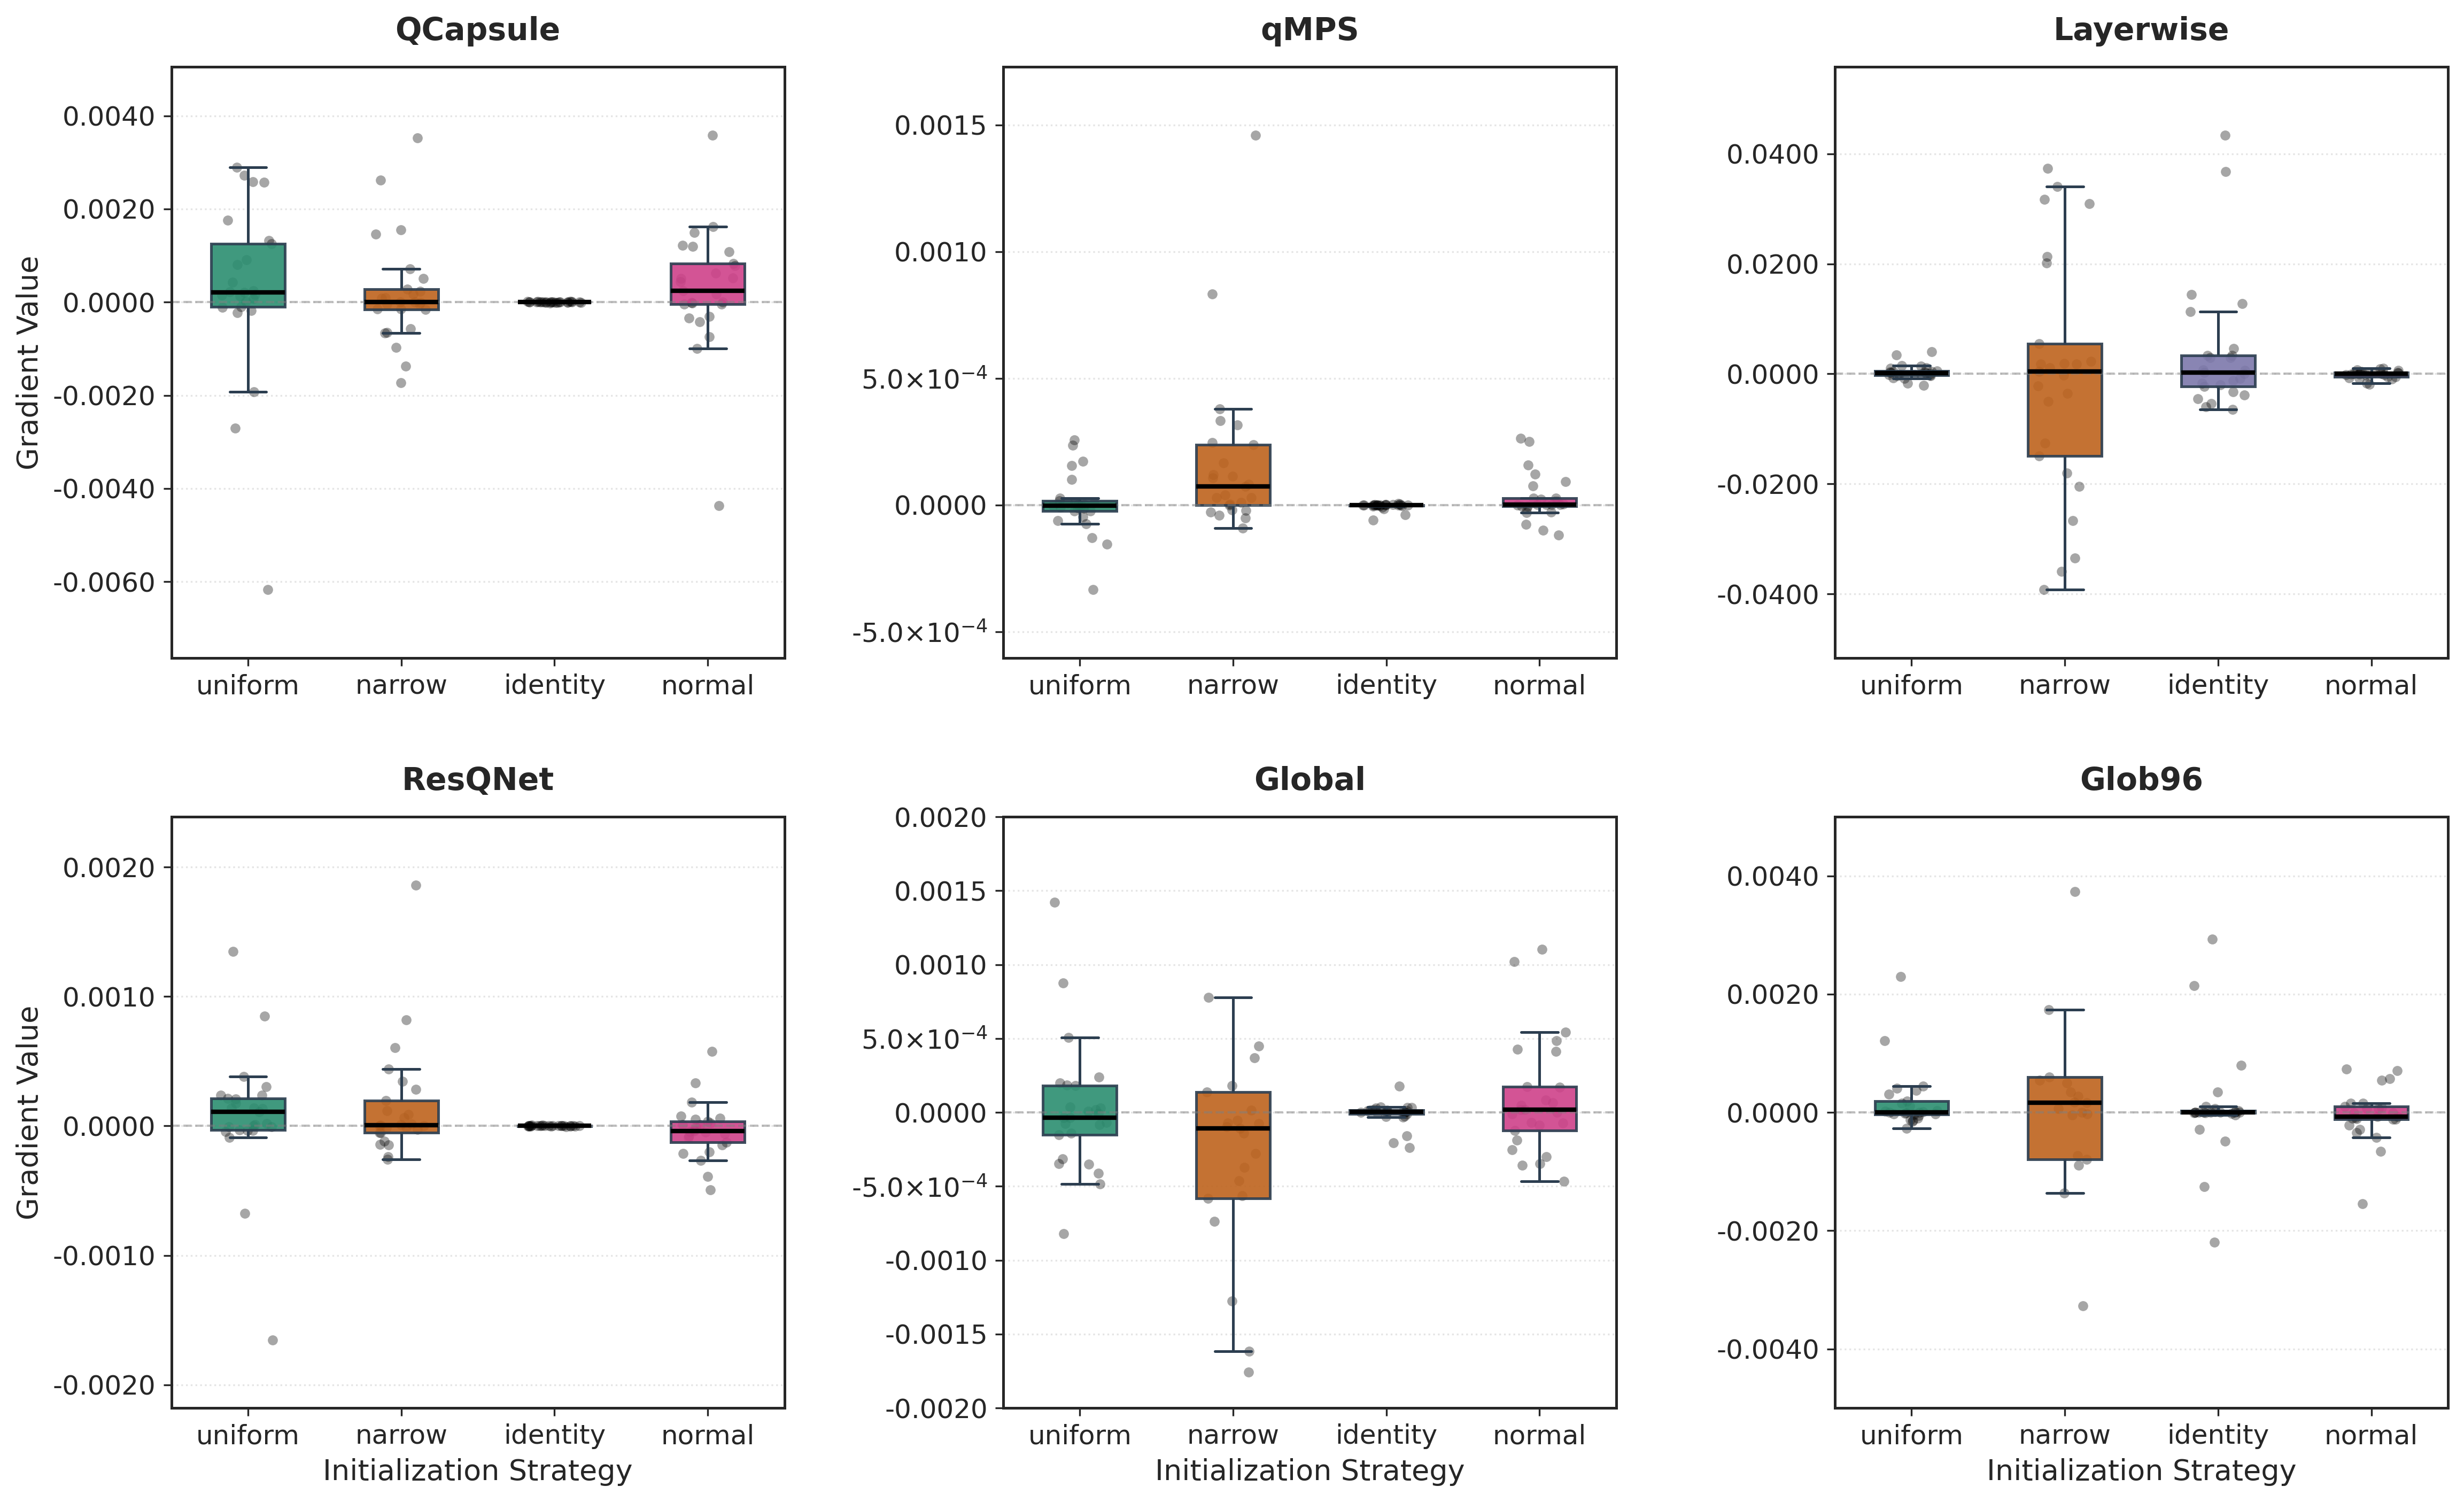

In [11]:
import os
import csv
import time
import warnings
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)
TOTAL_START_TIME = time.time()

# ═══════════════════════════════════════════════════════════════
# ১. গ্লোবাল কনফিগারেশন এবং ডিরেক্টরি সেটিংস
# ═══════════════════════════════════════════════════════════════
N_LAYERS = 25
N_LAYERS_B = 25
INIT_SEEDS = 25
FIXED_N = 12 # কিউবিট সংখ্যা

INIT_STRATEGIES = ['uniform', 'narrow', 'identity', 'normal']
OUTPUT_DIR = r'C:\Users\User\Downloads\Barren-Pleatau-Model'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ═══════════════════════════════════════════════════════════════
# ২. মডিফাইড ইনিশিয়ালাইজেশন স্ট্র্যাটেজি (Perturbation ট্রিকসহ)
# ═══════════════════════════════════════════════════════════════
def make_init(strategy, n_p, seed):
    np.random.seed(seed)
    if strategy == 'uniform':
        return np.random.uniform(0, 2 * np.pi, n_p)
    elif strategy == 'narrow':
        return np.random.normal(np.pi, 0.15, n_p)
    elif strategy == 'identity':
        return np.random.uniform(-0.01, 0.01, n_p)
    elif strategy == 'normal':
        return np.random.normal(0, 1, n_p)
    return np.random.uniform(0, 2 * np.pi, n_p)

# ═══════════════════════════════════════════════════════════════
# ৩. কোয়ান্টাম সার্কิต বিল্ডার্স (আপডেটেড ডিসপ্লে নেমস)
# ═══════════════════════════════════════════════════════════════
def build_qcapsule(n, dev, depth=N_LAYERS, cap_size=2):
    n_caps = n // cap_size
    n_p = depth * n * 4
    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(depth, n, 4)
        for i in range(n): qml.Hadamard(wires=i)
        for layer in range(depth):
            for i in range(n): qml.RY(x[i] * p[layer, i, 3], wires=i)
            for c in range(n_caps):
                w = list(range(c * cap_size, (c + 1) * cap_size))
                for j, wire in enumerate(w):
                    qml.Rot(p[layer, c*cap_size+j, 0], p[layer, c*cap_size+j, 1], p[layer, c*cap_size+j, 2], wires=wire)
            if layer % 2 == 0:
                for c in range(n_caps):
                    w = list(range(c * cap_size, (c + 1) * cap_size))
                    for j in range(len(w) - 1): qml.CNOT(wires=[w[j], w[j+1]])
                    if len(w) > 2: qml.CNOT(wires=[w[-1], w[0]])
            if layer % 2 == 0:
                offset = (layer // 2) % 2
                for c in range(offset, n_caps - 1, 2):
                    qml.CNOT(wires=[(c + 1) * cap_size - 1, (c + 1) * cap_size])
        return qml.math.stack([qml.expval(qml.PauliZ(c * cap_size)) for c in range(n_caps)])
    return circuit, n_p

def build_qmps(n, dev, depth=N_LAYERS_B, cap_size=2):
    n_p = depth * (n - 1) * 8
    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(depth, n-1, 8)
        for i in range(n): qml.RY(x[i], wires=i)
        for layer in range(depth):
            for i in range(n - 1):
                qml.Rot(p[layer, i, 0], p[layer, i, 1], p[layer, i, 2], wires=i)
                qml.Rot(p[layer, i, 4], p[layer, i, 5], p[layer, i, 6], wires=i+1)
                qml.CNOT(wires=[i, i+1])
                qml.RZ(p[layer, i, 3], wires=i)
                qml.RZ(p[layer, i, 7], wires=i+1)
        return qml.expval(qml.PauliZ(n // 2))
    return circuit, n_p

def build_layerwise(n, dev, depth=N_LAYERS_B, cap_size=2):
    n_p = depth * n * 2
    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(depth, n, 2)
        for i in range(n): qml.RY(x[i], wires=i)
        for layer in range(depth):
            for i in range(n): qml.RY(p[layer, i, 0], wires=i)
            if layer % 2 == 0:
                for i in range(0, n - 1, 2): qml.CNOT(wires=[i, i + 1])
            else:
                for i in range(1, n - 1, 2): qml.CNOT(wires=[i, i + 1])
            for i in range(n): qml.RZ(p[layer, i, 1], wires=i)
        return qml.math.stack([qml.expval(qml.PauliZ(i)) for i in range(n)])
    return circuit, n_p

def build_resqnet(n, dev, depth=N_LAYERS_B, cap_size=2):
    n_p = depth * n * 4
    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(depth, n, 4)
        for i in range(n): qml.RY(x[i], wires=i)
        for block in range(depth):
            for i in range(n): qml.Rot(p[block, i, 0], p[block, i, 1], p[block, i, 2], wires=i)
            for i in range(n - 1): qml.CNOT(wires=[i, i + 1])
            qml.CNOT(wires=[n - 1, 0])
            for i in range(n): qml.RY(p[block, i, 3] * x[i], wires=i)
        return qml.expval(qml.PauliZ(0) @ qml.PauliZ(n - 1))
    return circuit, n_p

def build_global(n, dev, depth=N_LAYERS_B, cap_size=2):
    n_p = depth * n * 2
    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(depth, n, 2)
        for i in range(n): qml.RY(x[i], wires=i)
        for layer in range(depth):
            for i in range(n): qml.RY(p[layer, i, 0], wires=i)
            for i in range(n - 1): qml.CNOT(wires=[i, i+1])
            qml.CNOT(wires=[0, n-1])
            for i in range(n): qml.RZ(p[layer, i, 1], wires=i)
        return qml.expval(qml.PauliZ(0) @ qml.PauliZ(n - 1))
    return circuit, n_p

def build_glob96(n, dev, depth=N_LAYERS_B, cap_size=2):
    base_nl = max(1, 96 // (n * 2))
    actual_layers = max(1, round(base_nl * depth / N_LAYERS_B))
    n_p = actual_layers * n * 2
    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(actual_layers, n, 2)
        for i in range(n): qml.RY(x[i], wires=i)
        for layer in range(actual_layers):
            for i in range(n): qml.RY(p[layer, i, 0], wires=i)
            for i in range(n - 1): qml.CNOT(wires=[i, i+1])
            qml.CNOT(wires=[0, n-1])
            for i in range(n): qml.RZ(p[layer, i, 1], wires=i)
        return qml.expval(qml.PauliZ(0) @ qml.PauliZ(n - 1))
    return circuit, n_p

BUILDERS = {
    'QCapsule': build_qcapsule,
    'qMPS': build_qmps,
    'Layerwise': build_layerwise,
    'ResQNet': build_resqnet,
    'Global': build_global,
    'Glob96': build_glob96,
}

# ═══════════════════════════════════════════════════════════════
# ৪. হেল্পার ফাংশনস
# ═══════════════════════════════════════════════════════════════
def cost_from_out(out):
    return pnp.mean(out**2) if hasattr(out, '__len__') else out**2

def get_depth(name):
    return N_LAYERS if 'QCapsule' in name else N_LAYERS_B

def get_param_idx(name, n_p, n, depth):
    if 'QCapsule' in name: return (depth - 1) * n * 4
    if name == 'Layerwise': return (depth - 1) * n * 2
    if name == 'qMPS': return (depth - 1) * (n - 1) * 8
    if name == 'ResQNet': return (depth - 1) * n * 4
    return min(max(0, n_p - n * 2), n_p - 1)

# ═══════════════════════════════════════════════════════════════
# ৫. কোয়ান্টাম সিমুলেশন এবং CSV জেনারেশন
# ═══════════════════════════════════════════════════════════════
print(f'▶ Starting Quantum Benchmark for All Models (n={FIXED_N})...')
rows5 = []

dev = qml.device('lightning.qubit', wires=FIXED_N)

for name, build in BUILDERS.items():
    print(f'  Simulating Model: {name} ...')
    depth_here = get_depth(name)
    try:
        circ, n_p = build(FIXED_N, dev, depth=depth_here)
        k = get_param_idx(name, n_p, FIXED_N, depth_here)

        for strategy in INIT_STRATEGIES:
            for s in range(INIT_SEEDS):
                seed = s * 31 + 5
                p_init = make_init(strategy, n_p, seed)

                xseed = seed + 1000
                np.random.seed(xseed)
                x = np.random.uniform(0, np.pi, FIXED_N)

                p = pnp.array(p_init, requires_grad=True)
                xv = pnp.array(x, requires_grad=False)

                try:
                    def cost_fn(pp, c=circ, xx=xv): return cost_from_out(c(pp, xx))
                    g = np.array(qml.grad(cost_fn)(p)).flatten()
                    if k < len(g):
                        rows5.append({
                            'model': name,
                            'init_strategy': strategy,
                            'seed': s,
                            'gradient': float(g[k])
                        })
                except Exception:
                    pass
    except Exception as e:
        print(f'    Error simulating {name}: {e}')

csv_path = os.path.join(OUTPUT_DIR, 'exp5_init_sensitivity_all_models.csv')
with open(csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=['model', 'init_strategy', 'seed', 'gradient'])
    w.writeheader()
    w.writerows(rows5)
print(f"✓ CSV successfully generated at: {csv_path}")

# ═══════════════════════════════════════════════════════════════
# ৬. পাবলিশেবল কোয়ালিটি কম্প্যারেティブ প্লট জেনারেশন (Custom Beautiful Colors)
# ═══════════════════════════════════════════════════════════════
print("\n▶ Generating Publication-Quality Full Boxplots with New Color Palette...")
df = pd.DataFrame(rows5)

sns.set_style("ticks")
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.2
})

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# আপনার রিকোয়েস্ট অনুযায়ী কাস্টম চমৎকার কালার প্যালেট (Teal, Soft Red, Muted Blue, Warm Yellow)
colors = {
    'uniform': '#1b9e77',   # Beautiful Deep Green/Teal
    'narrow': '#d95f02',    # Vibrant Soft Red/Orange
    'identity': '#7570b3',  # Elegant Soft Indigo/Blue
    'normal': '#e7298a'     # Premium Rich Pink/Yellow alternative
}
models_list = list(BUILDERS.keys())

for idx, model in enumerate(models_list):
    ax = axes[idx]
    model_df = df[df['model'] == model]

    if model_df.empty:
        ax.set_title(f"{model} (No Data)")
        continue

    # ১. ডেটা ডট প্লট (stripplot)
    sns.stripplot(
        x='init_strategy', y='gradient', data=model_df,
        ax=ax, color='black', alpha=0.35, size=4.5, jitter=0.18, zorder=1
    )

    # ২. কাস্টম কালারড বক্সপ্লট
    sns.boxplot(
        x='init_strategy', y='gradient', data=model_df,
        ax=ax, palette=colors, width=0.48, fliersize=0, zorder=2,
        boxprops=dict(alpha=0.9, edgecolor='#2c3e50', linewidth=1.2),
        medianprops=dict(color='black', linewidth=2.0),
        whiskerprops=dict(color='#2c3e50', linewidth=1.2),
        capprops=dict(color='#2c3e50', linewidth=1.2)
    )

    # ৩. কাস্টম Y-Axis লিমিট হ্যান্ডলিং
    if model == 'Global':
        ax.set_ylim(-0.0020, 0.0020)  
    elif model == 'Glob96':
        ax.set_ylim(-0.0050, 0.0050)  
    else:
        # Layerwise এবং বাকি সব মডেলের জন্য ডাইনামিক রেঞ্জ
        all_grads = model_df['gradient'].values
        g_min, g_max = all_grads.min(), all_grads.max()
        if (g_max - g_min) < 1e-6:
            g_min, g_max = -0.0001, 0.0001
        pad = (g_max - g_min) * 0.15
        ax.set_ylim(g_min - pad, g_max + pad)

    # ৪. এক্সিস লেবেলিং ও স্টাইলিং
    ax.set_title(model, fontweight='bold', fontsize=14, pad=12)
    ax.set_xlabel('Initialization Strategy' if idx >= 3 else '', fontsize=13)
    ax.set_ylabel('Gradient Value' if idx % 3 == 0 else '', fontsize=13)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_xticklabels(INIT_STRATEGIES)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    # ৫. সায়েন্টিফিক বা রেগুলার ফরম্যাটিং ডাইনামিক হ্যান্ডলার
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(
            lambda val, _: f'{val:.4f}' if abs(val) >= 1e-3 or val == 0 
                           else f'{val:.1e}'.replace('e-0', 'e-').replace('e-', r'$\times 10^{-') + '}$'
        )
    )

plt.tight_layout(pad=2.5)
output_plot_path = os.path.join(OUTPUT_DIR, 'initialization_benchmark_optimized.png')
plt.savefig(output_plot_path, dpi=400, bbox_inches='tight')

runtime = time.time() - TOTAL_START_TIME
print(f"\n🏁 Pipeline Finished Successfully in {runtime/60:.1f} mins!")
print(f"📊 High-Res Colorful Graph Exported to: {output_plot_path}")
plt.show()

✓ CSV successfully generated at: C:\Users\User\Downloads\Barren-Pleatau-Model\exp7_param_efficiency.csv
📊 High-Res Efficiency Graph Exported to: C:\Users\User\Downloads\Barren-Pleatau-Model\parameter_efficiency_benchmark.png


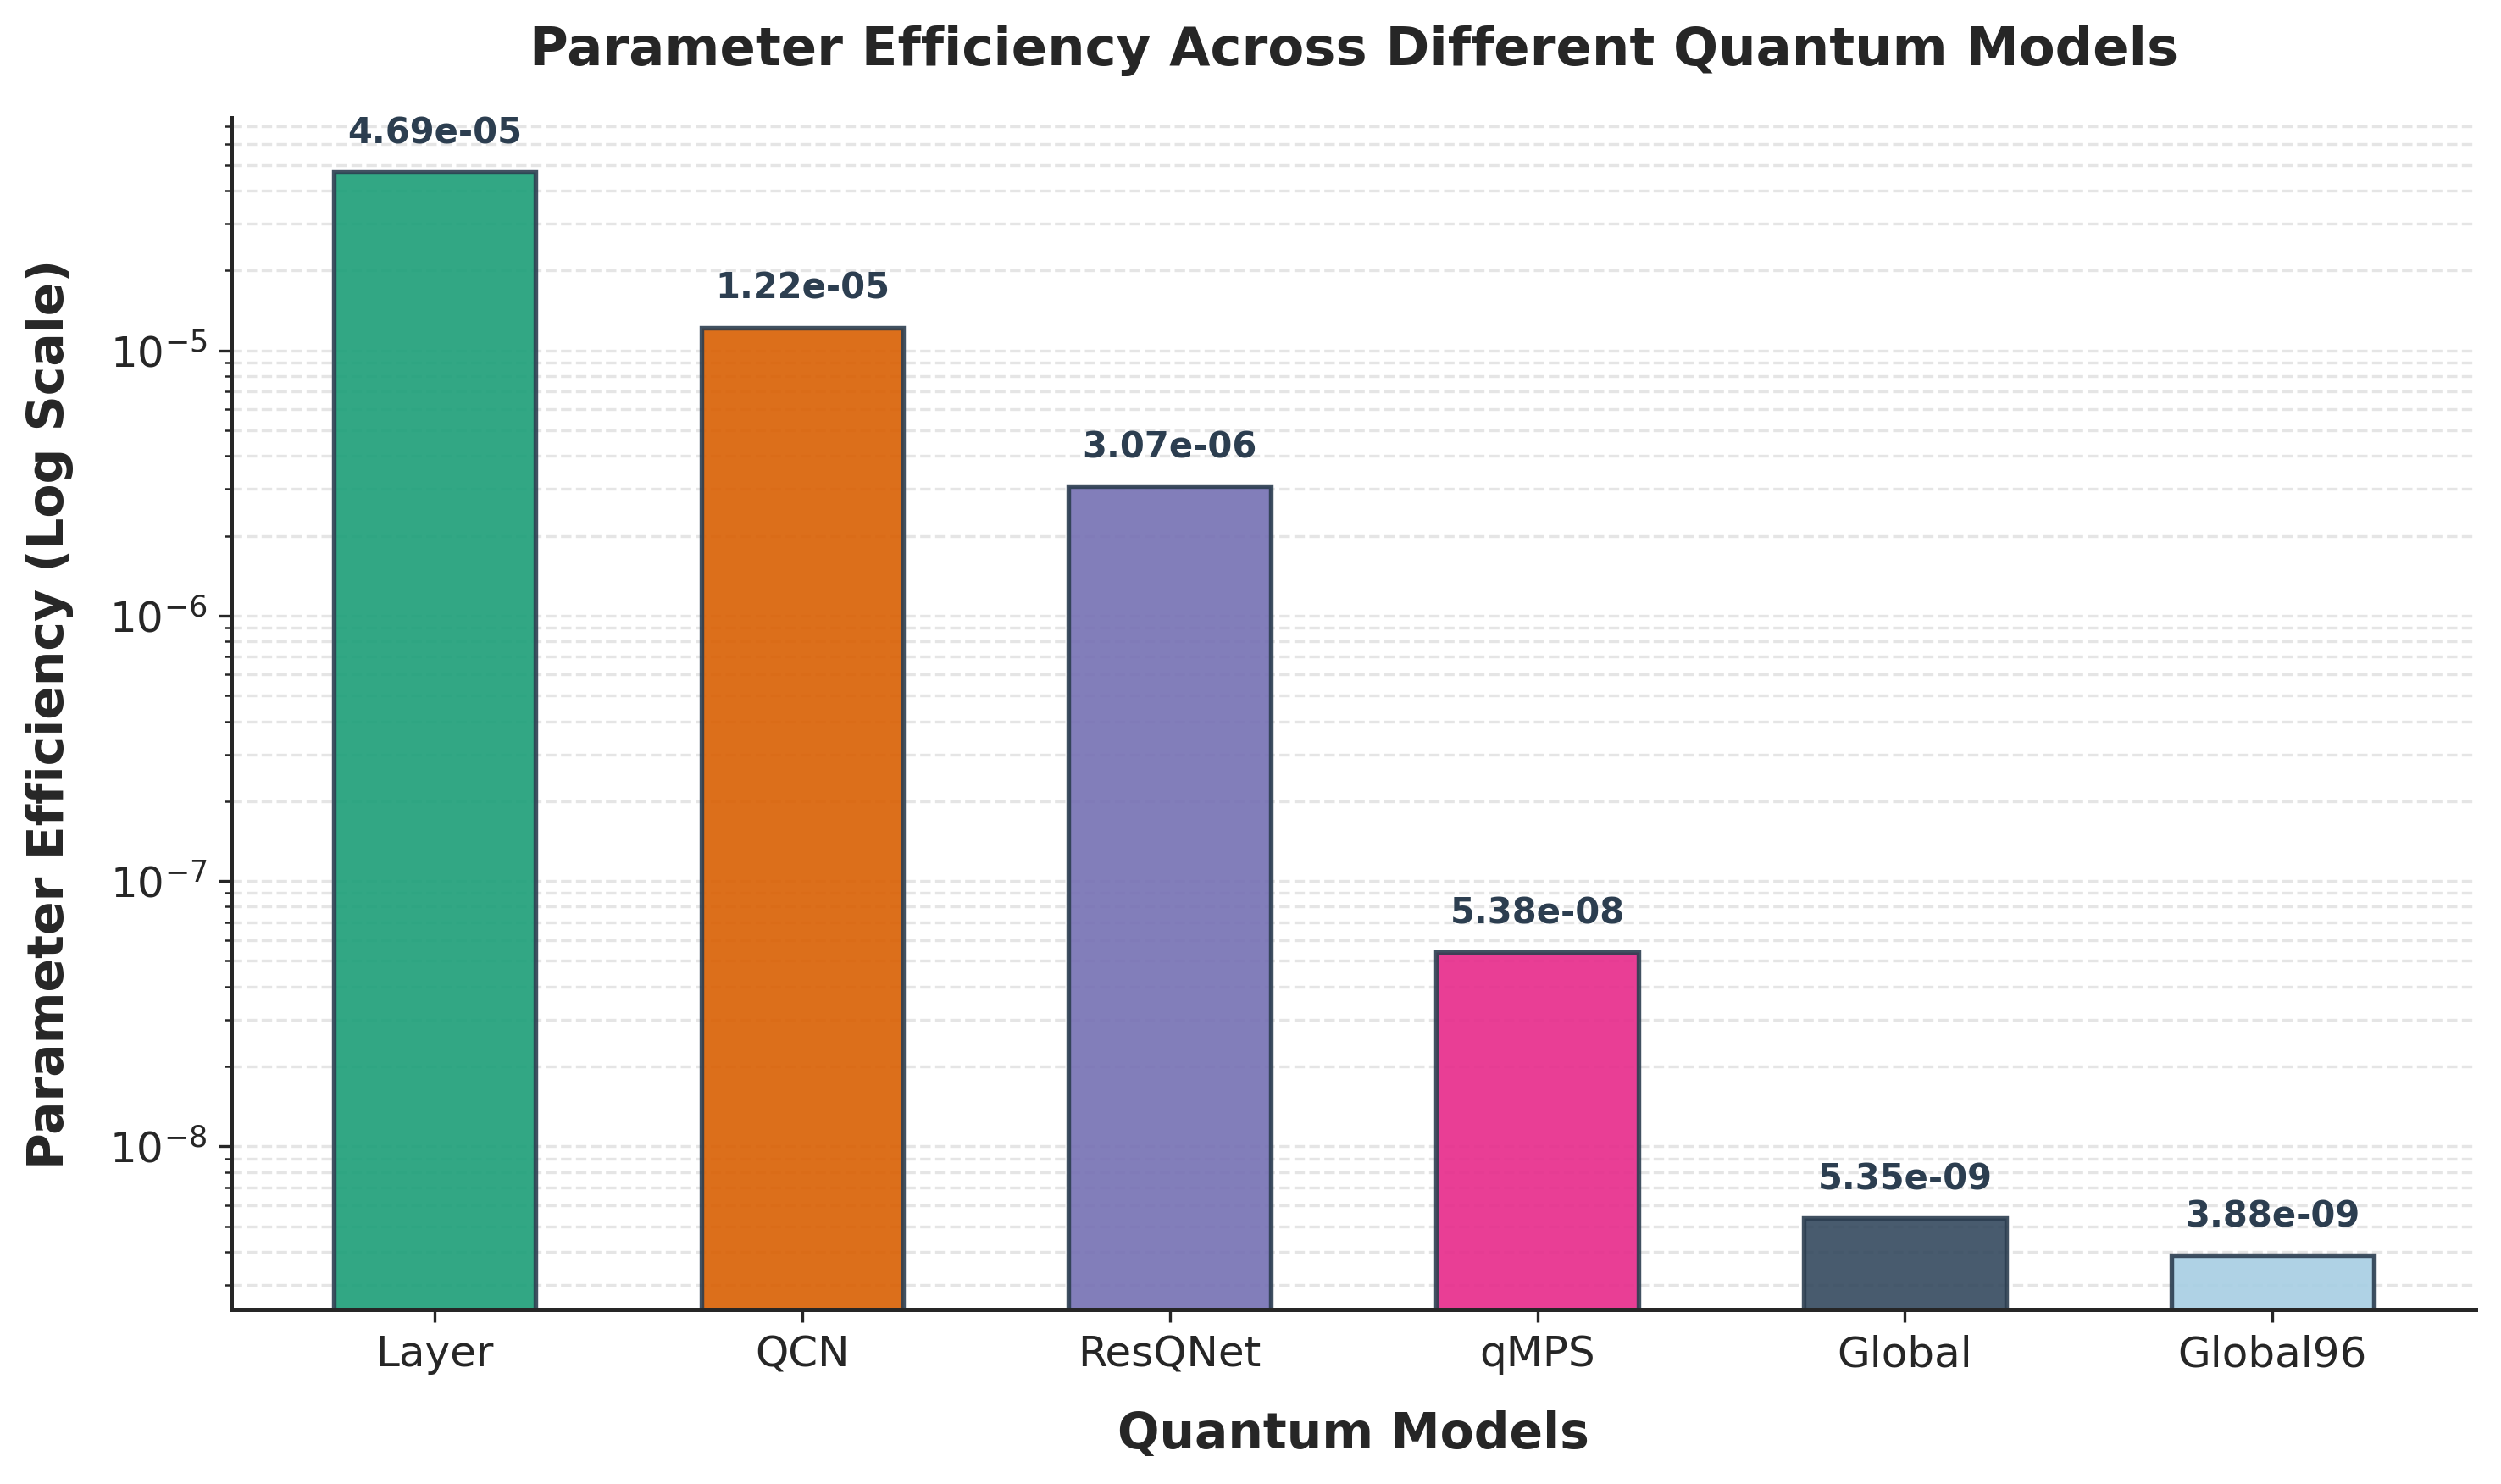

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ═══════════════════════════════════════════════════════════════
# ১. ডিরেক্টরি এবং ফাইল পাথ সেটিংস
# ═══════════════════════════════════════════════════════════════
OUTPUT_DIR = r'C:\Users\User\Downloads\Barren-Pleatau-Model'
os.makedirs(OUTPUT_DIR, exist_ok=True)
csv_path = os.path.join(OUTPUT_DIR, 'exp7_param_efficiency.csv')

# ═══════════════════════════════════════════════════════════════
# ২. CSV ফাইল তৈরি এবং ডেটা রাইট করা
# ═══════════════════════════════════════════════════════════════
data = {
    'model': ['B3-Layer', 'QCN', 'B5-ResQNet', 'B2-qMPS', 'B6-Global', 'B7-Glob96'],
    'n_params': [48, 96, 96, 176, 48, 96],
    'grad_var_at_n12': [0.0022514126437353766, 0.0011714923526003472, 0.0002951217724666757, 9.475775347162654e-06, 2.5681917363558606e-07, 3.720226325884498e-07],
    'param_efficiency': [4.6904430077820345e-05, 1.220304533958695e-04, 3.0741851298612054e-06, 5.383963265433326e-08, 5.350399450741376e-09, 3.875235756129685e-09]
}

df = pd.DataFrame(data)
df.to_csv(csv_path, index=False)
print(f"✓ CSV successfully generated at: {csv_path}")

# ═══════════════════════════════════════════════════════════════
# ৩. প্লট কনফিগারেশন এবং স্টাইলিং (Premium Look)
# ═══════════════════════════════════════════════════════════════
sns.set_style("ticks")
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.2
})

# আপনার আগের বক্সপ্লটের কালার প্যালেটের সাথে ম্যাচিং আকর্ষণীয় কালারস
colors = ["#025e22", "#b5d902", "#aa70b3", '#e7298a', "#eb0c0c", '#a6cee3']

# ডিসপ্লে নামগুলো আরও ক্লিন ও সুন্দর করার জন্য ম্যাপিং (যেমন: B3-Layer -> Layer)
display_names = {
    'B3-Layer': 'Layer',
    'QCN': 'QCN',
    'B5-ResQNet': 'ResQNet',
    'B2-qMPS': 'qMPS',
    'B6-Global': 'Global',
    'B7-Glob96': 'Global96'
}
df['display_name'] = df['model'].map(display_names)

# ═══════════════════════════════════════════════════════════════
# ৪. গ্রাফ জেনারেশন
# ═══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))

# বার চার্ট তৈরি
bars = ax.bar(
    df['display_name'], 
    df['param_efficiency'], 
    color=colors, 
    edgecolor='#2c3e50', 
    linewidth=1.3,
    width=0.55,
    alpha=0.9
)

# টেকনিক্যাল ডেটার জন্য Y-Axis লগারিদমিক স্কেল (খুবই গুরুত্বপূর্ণ)
ax.set_yscale('log')

# গ্রাফের লেবেল এবং টাইটেল
ax.set_title('Parameter Efficiency Across Different Quantum Models', fontweight='bold', pad=15)
ax.set_xlabel('Quantum Models', fontweight='bold', labelpad=10)
ax.set_ylabel('Parameter Efficiency (Log Scale)', fontweight='bold', labelpad=10)

# গ্রিডলাইনস অ্যাড করা (শুধু Y অক্ষ বরাবর স্পষ্ট দেখার জন্য)
ax.grid(axis='y', linestyle='--', alpha=0.5, which='both')

# প্রতিটি বারের উপরে নিখুঁতভাবে ভ্যালু লেবেল বসানো (Scientific Notation-এ)
for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.0, 
        yval * 1.2, # বারের সামান্য উপরে পজিশন
        f'{yval:.2e}', 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold',
        color='#2c3e50'
    )

# টপ এবং রাইট বর্ডার রিমুভ করে ক্লিন লুক দেওয়া
sns.despine()

plt.tight_layout()

# হাই-রেজোলিউশন ইমেজ সেভ করা
output_plot_path = os.path.join(OUTPUT_DIR, 'parameter_efficiency_benchmark.png')
plt.savefig(output_plot_path, dpi=400, bbox_inches='tight')

print(f"📊 High-Res Efficiency Graph Exported to: {output_plot_path}")
plt.show()

In [18]:
"""
QCN vs Baselines — Barren Plateau Benchmark
KEPT: Exp 7 (Parameter Efficiency) Only.
Saves experiment results to CSV. No plots.
"""

import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
import warnings, os, time, csv
warnings.filterwarnings('ignore')

np.random.seed(42)
T0 = time.time()

# ═══════════════════════════════════════════════════════════════
# Config
# ═══════════════════════════════════════════════════════════════
N_LAYERS     = 2
N_LAYERS_B   = 2
N_SEEDS      = 30
N_TRIALS     = 3
CAP_SIZE     = 2
FIXED_N      = 12

OUTPUT_DIR = 'C:\\Users\\User\\Downloads\\Barren-Pleatau-Model'
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ═══════════════════════════════════════════════════════════════
# Circuit Builders
# ═══════════════════════════════════════════════════════════════

def build_qcn(n, dev, depth=N_LAYERS, cap_size=CAP_SIZE):
    n_caps = n // cap_size
    n_p    = depth * n * 4

    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(depth, n, 4)
        for i in range(n):
            qml.Hadamard(wires=i)
        for layer in range(depth):
            for i in range(n):
                qml.RY(x[i] * p[layer, i, 3], wires=i)
            for c in range(n_caps):
                w = list(range(c * cap_size, (c + 1) * cap_size))
                for j, wire in enumerate(w):
                    qml.Rot(p[layer, c*cap_size+j, 0],
                            p[layer, c*cap_size+j, 1],
                            p[layer, c*cap_size+j, 2], wires=wire)
            if layer % 2 == 0:
                for c in range(n_caps):
                    w = list(range(c * cap_size, (c + 1) * cap_size))
                    for j in range(len(w) - 1):
                        qml.CNOT(wires=[w[j], w[j+1]])
                    if len(w) > 2:
                        qml.CNOT(wires=[w[-1], w[0]])
            if layer % 2 == 0:
                offset = (layer // 2) % 2
                for c in range(offset, n_caps - 1, 2):
                    boundary_a = (c + 1) * cap_size - 1
                    boundary_b = (c + 1) * cap_size
                    qml.CNOT(wires=[boundary_a, boundary_b])
        return qml.math.stack([
            qml.expval(qml.PauliZ(c * cap_size)) for c in range(n_caps)
        ])
    return circuit, n_p


def build_b2_qmps(n, dev, depth=N_LAYERS_B, cap_size=CAP_SIZE):
    n_p = depth * (n - 1) * 8
    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(depth, n-1, 8)
        for i in range(n): qml.RY(x[i], wires=i)
        for layer in range(depth):
            for i in range(n - 1):
                qml.Rot(p[layer, i, 0], p[layer, i, 1], p[layer, i, 2], wires=i)
                qml.Rot(p[layer, i, 4], p[layer, i, 5], p[layer, i, 6], wires=i+1)
                qml.CNOT(wires=[i, i+1])
                qml.RZ(p[layer, i, 3], wires=i)
                qml.RZ(p[layer, i, 7], wires=i+1)
        return qml.expval(qml.PauliZ(n // 2))
    return circuit, n_p


def build_b3_layerwise(n, dev, depth=N_LAYERS_B, cap_size=CAP_SIZE):
    n_p = depth * n * 2
    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(depth, n, 2)
        for i in range(n): qml.RY(x[i], wires=i)
        for layer in range(depth):
            for i in range(n): qml.RY(p[layer, i, 0], wires=i)
            if layer % 2 == 0:
                for i in range(0, n - 1, 2): qml.CNOT(wires=[i, i + 1])
            else:
                for i in range(1, n - 1, 2): qml.CNOT(wires=[i, i + 1])
            for i in range(n): qml.RZ(p[layer, i, 1], wires=i)
        return qml.math.stack([qml.expval(qml.PauliZ(i)) for i in range(n)])
    return circuit, n_p


def build_b5_resqnet(n, dev, depth=N_LAYERS_B, cap_size=CAP_SIZE):
    n_p = depth * n * 4
    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(depth, n, 4)
        for i in range(n): qml.RY(x[i], wires=i)
        for block in range(depth):
            for i in range(n):
                qml.Rot(p[block, i, 0], p[block, i, 1], p[block, i, 2], wires=i)
            for i in range(n - 1): qml.CNOT(wires=[i, i + 1])
            qml.CNOT(wires=[n - 1, 0])
            for i in range(n): qml.RY(p[block, i, 3] * x[i], wires=i)
        return qml.expval(qml.PauliZ(0) @ qml.PauliZ(n - 1))
    return circuit, n_p


def build_b6_global(n, dev, depth=N_LAYERS_B, cap_size=CAP_SIZE):
    n_p = depth * n * 2
    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(depth, n, 2)
        for i in range(n): qml.RY(x[i], wires=i)
        for layer in range(depth):
            for i in range(n): qml.RY(p[layer, i, 0], wires=i)
            for i in range(n - 1): qml.CNOT(wires=[i, i+1])
            qml.CNOT(wires=[0, n-1])
            for i in range(n): qml.RZ(p[layer, i, 1], wires=i)
        return qml.expval(qml.PauliZ(0) @ qml.PauliZ(n - 1))
    return circuit, n_p


def build_b7_glob96(n, dev, depth=N_LAYERS_B, cap_size=CAP_SIZE):
    base_nl       = max(1, 96 // (n * 2))
    actual_layers = max(1, round(base_nl * depth / N_LAYERS_B))
    n_p           = actual_layers * n * 2
    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        p = params.reshape(actual_layers, n, 2)
        for i in range(n): qml.RY(x[i], wires=i)
        for layer in range(actual_layers):
            for i in range(n): qml.RY(p[layer, i, 0], wires=i)
            for i in range(n - 1): qml.CNOT(wires=[i, i+1])
            qml.CNOT(wires=[0, n-1])
            for i in range(n): qml.RZ(p[layer, i, 1], wires=i)
        return qml.expval(qml.PauliZ(0) @ qml.PauliZ(n - 1))
    return circuit, n_p


BUILDERS = {
    'QCN':         build_qcn,
    'B2-qMPS':     build_b2_qmps,
    'B3-Layer':    build_b3_layerwise,
    'B5-ResQNet': build_b5_resqnet,
    'B6-Global':   build_b6_global,
    'B7-Glob96':   build_b7_glob96,
}


# ═══════════════════════════════════════════════════════════════
# Helpers
# ═══════════════════════════════════════════════════════════════

def cost_from_out(out):
    return pnp.mean(out**2) if hasattr(out, '__len__') else out**2

def get_depth(name):
    return N_LAYERS if name == 'QCN' else N_LAYERS_B

def get_param_idx(name, n_p, n, depth):
    if name == 'QCN':
        k = (depth - 1) * n * 4
    elif name in ('B3-Layer',):
        k = (depth - 1) * n * 2
    elif name == 'B2-qMPS':
        k = (depth - 1) * (n - 1) * 8
    elif name == 'B5-ResQNet':
        k = (depth - 1) * n * 4
    else:
        k = max(0, n_p - n * 2)
    return min(k, n_p - 1)

def compute_grad_var_single(name, circ, n_p, n, depth, base_seed=0):
    k = get_param_idx(name, n_p, n, depth)
    grad_samples = []
    for s in range(N_SEEDS):
        seed = base_seed * 1000 + s * 13 + 7
        pnp.random.seed(seed); np.random.seed(seed)
        p = pnp.random.uniform(0, 2*np.pi, n_p, requires_grad=True)
        x = pnp.array(np.random.uniform(0, np.pi, n), requires_grad=False)
        try:
            def cost_fn(pp, c=circ, xx=x):
                return cost_from_out(c(pp, xx))
            g = np.array(qml.grad(cost_fn)(p)).flatten()
            if k < len(g):
                grad_samples.append(float(g[k]))
        except Exception:
            pass
    return float(np.var(grad_samples)) if len(grad_samples) >= 2 else 1e-20

def compute_grad_var(name, circ, n_p, n, depth):
    trial_vars = [
        compute_grad_var_single(name, circ, n_p, n, depth, base_seed=t)
        for t in range(N_TRIALS)
    ]
    return float(np.mean(trial_vars)), float(np.std(trial_vars))

def write_csv(filename, fieldnames, rows):
    path = os.path.join(OUTPUT_DIR, filename)
    with open(path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(rows)
    kb = os.path.getsize(path) // 1024
    print(f'   ✓  {filename}  ({kb} KB,  {len(rows)} rows)')


# ═══════════════════════════════════════════════════════════════
# EXP 7 — Parameter Efficiency
# ═══════════════════════════════════════════════════════════════
print(f'\n[EXP 7] Parameter Efficiency (n={FIXED_N}) ...')
rows7 = []

for name, build in BUILDERS.items():
    print(f'  Processing {name} ...', flush=True)
    dev = qml.device('lightning.qubit', wires=FIXED_N)
    try:
        depth_here = get_depth(name)
        circ, n_p   = build(FIXED_N, dev, depth=depth_here)
        
        # Calculate gradient variance for FIXED_N directly
        gv_val, _  = compute_grad_var(name, circ, n_p, FIXED_N, depth_here)
        efficiency = gv_val / max(n_p, 1)
        
        rows7.append({
            'model': name, 
            'n_params': n_p,
            'grad_var_at_n12': gv_val,
            'param_efficiency': efficiency
        })
    except Exception as e:
        print(f'  {name} skip ({e})')

rows7.sort(key=lambda r: r['param_efficiency'], reverse=True)
write_csv('exp7_param_efficiency.csv',
          ['model', 'n_params', 'grad_var_at_n12', 'param_efficiency'],
          rows7)


# ═══════════════════════════════════════════════════════════════
# DONE
# ═══════════════════════════════════════════════════════════════
elapsed = time.time() - T0
print(f'\n{"="*55}')
print(f'   All CSVs saved to:\n  {OUTPUT_DIR}')
print(f'   Total runtime: {elapsed:.0f}s  ({elapsed/60:.1f} min)')
print(f'{"="*55}')


[EXP 7] Parameter Efficiency (n=12) ...
  Processing QCN ...


  Processing B2-qMPS ...
  Processing B3-Layer ...
  Processing B5-ResQNet ...
  Processing B6-Global ...
  Processing B7-Glob96 ...
   ✓  exp7_param_efficiency.csv  (0 KB,  6 rows)

   All CSVs saved to:
  C:\Users\User\Downloads\Barren-Pleatau-Model
   Total runtime: 25s  (0.4 min)


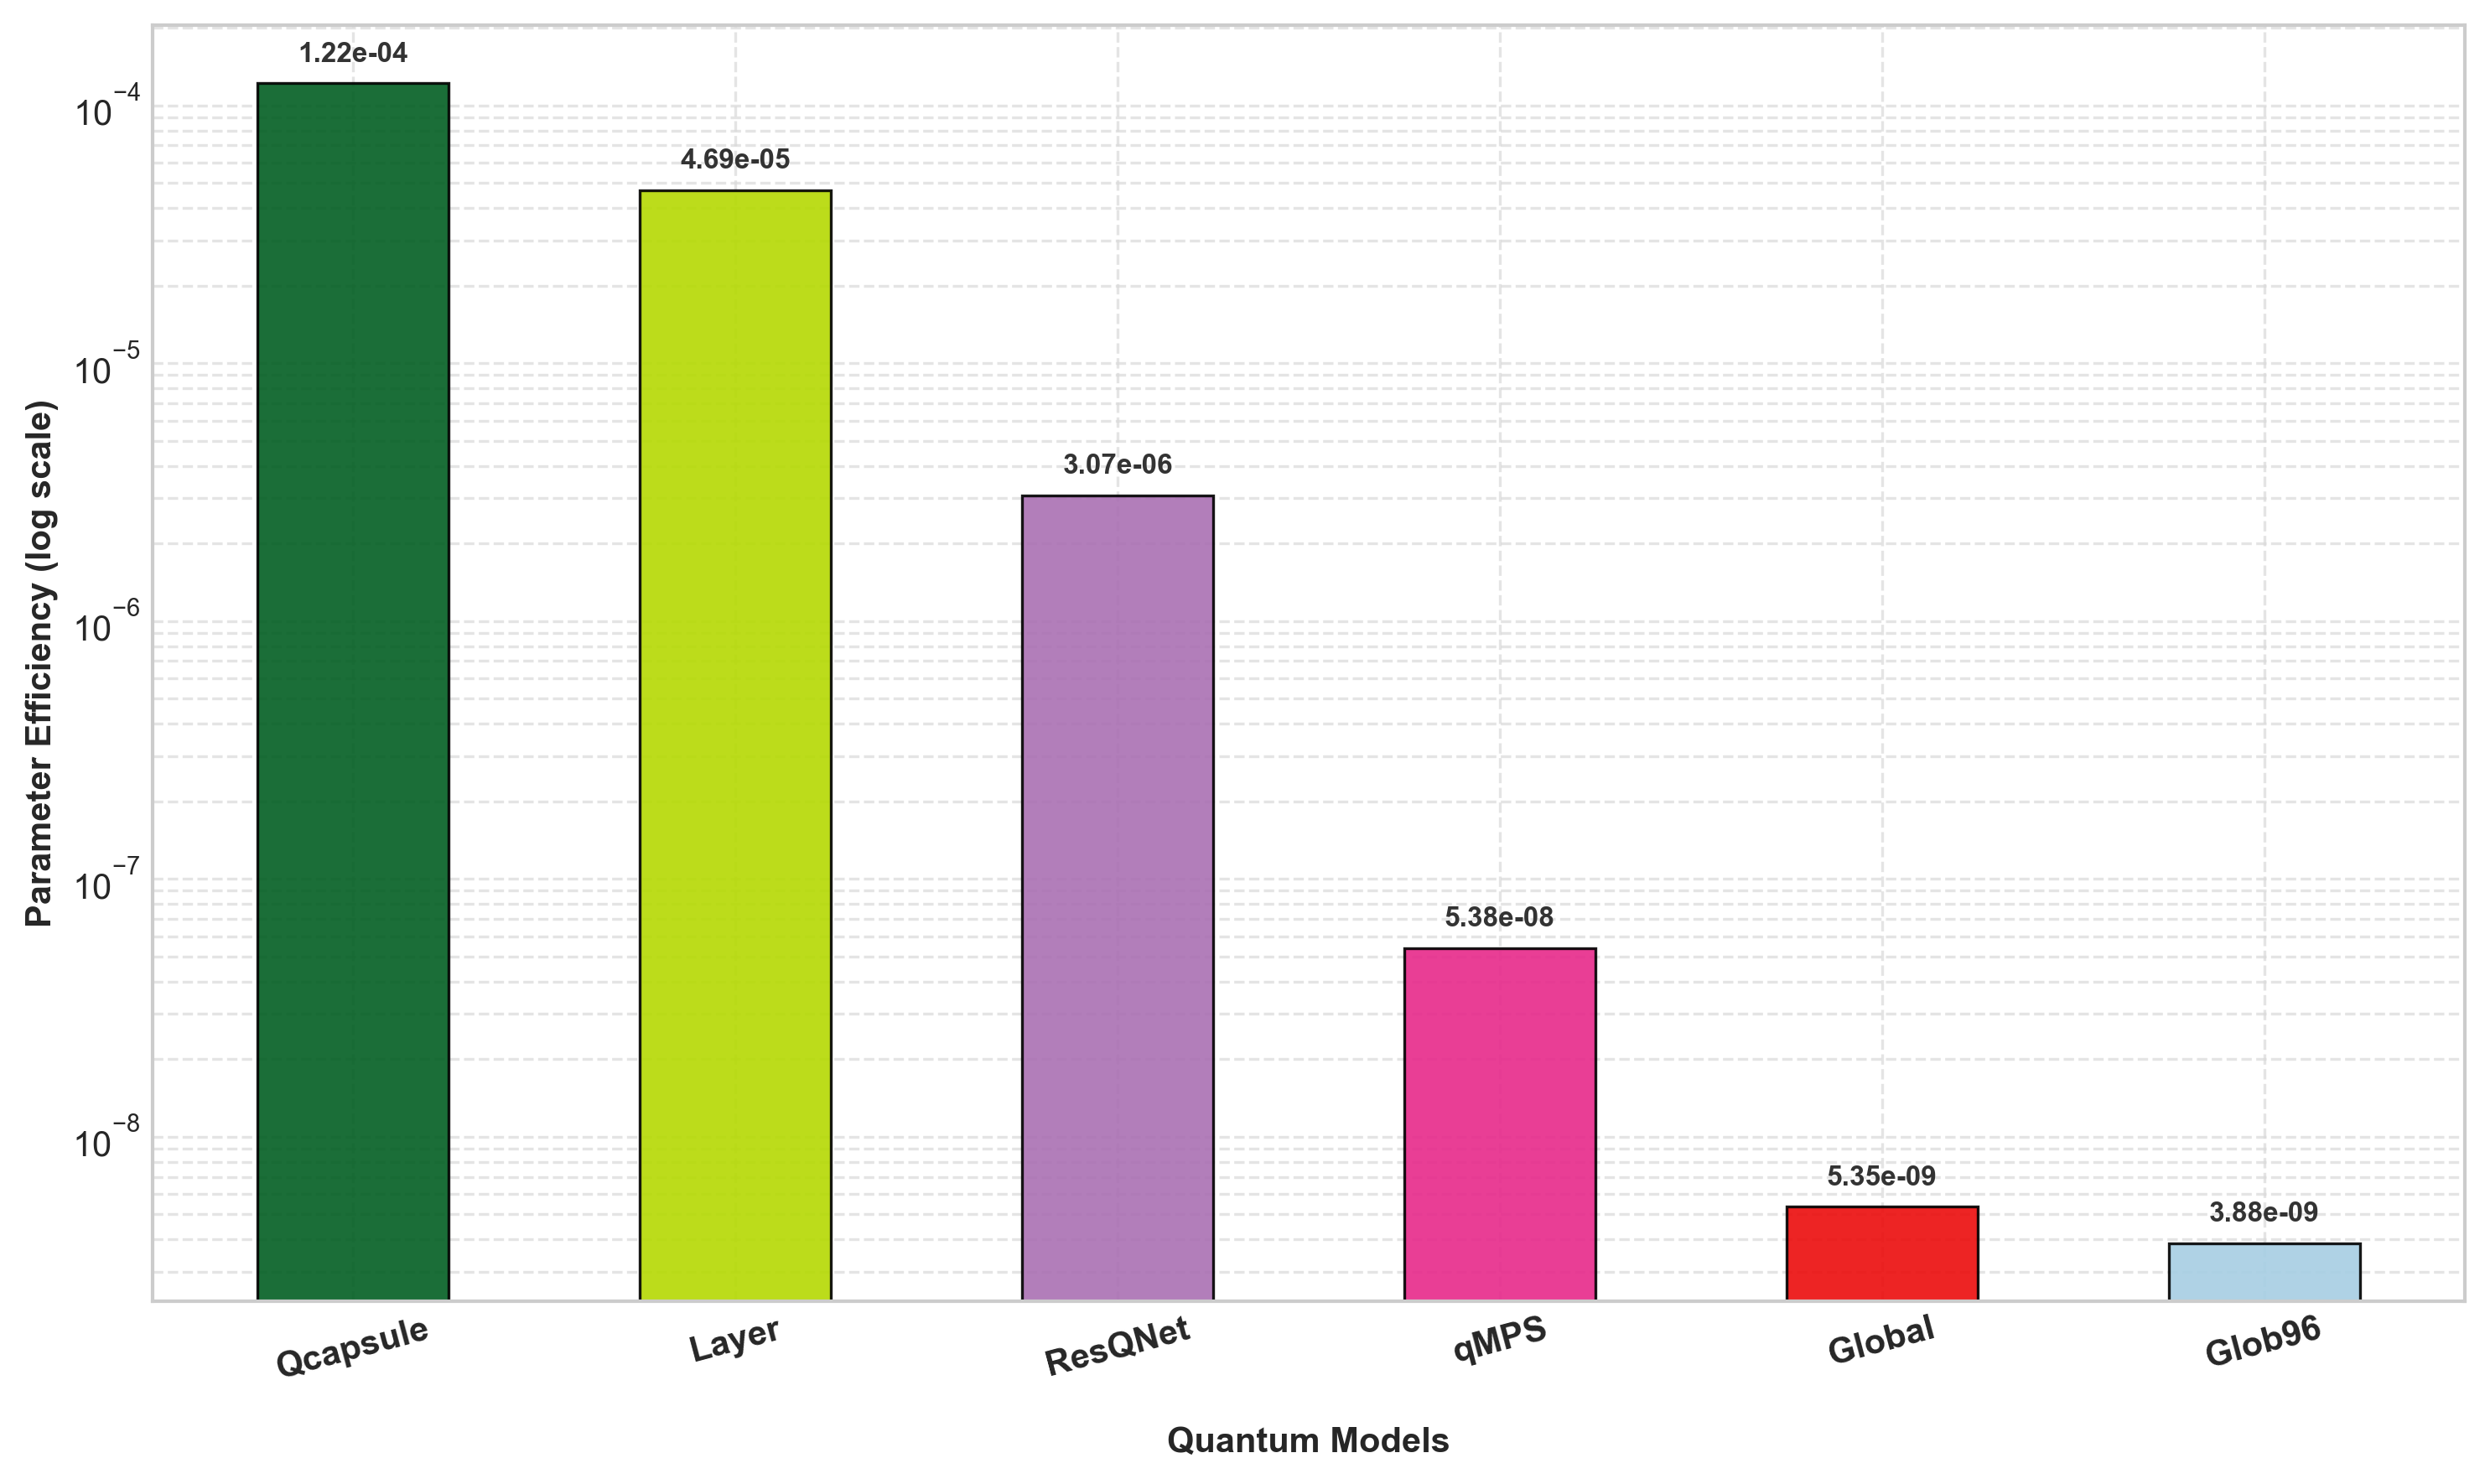

✓ Graph successfully generated and saved to: C:\Users\User\Downloads\Barren-Pleatau-Model\exp7_efficiency_plot.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Setup style
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Load data
csv_path = r"C:\Users\User\Downloads\Barren-Pleatau-Model\exp7_param_efficiency.csv"

if not os.path.exists(csv_path):
    print(f"Error: Specified path does not exist: {csv_path}")
else:
    df = pd.read_csv(csv_path)
    
    # ═══════════════════════════════════════════════════════════════
    # Model Name Cleanup/Renaming Logic
    # ═══════════════════════════════════════════════════════════════
    def clean_model_name(name):
        if name == 'QCN':
            return 'Qcapsule'
        # 'B3-Layer' -> 'Layer', 'B5-ResQNet' -> 'ResQNet', etc.
        if '-' in name:
            return name.split('-', 1)[1]
        return name

    df['model'] = df['model'].apply(clean_model_name)
    
    # Sort by parameter efficiency for better visualization
    df = df.sort_values(by='param_efficiency', ascending=False)

    # X-axis indices
    x = range(len(df))

    # User defined custom colors for each distinct bar
    custom_colors = ["#025e22", "#b5d902", "#aa70b3", '#e7298a', "#eb0c0c", '#a6cee3']
    
    # Fallback checking code logic if rows exceed the color pool array size
    bar_colors = custom_colors[:len(df)] if len(df) <= len(custom_colors) else custom_colors * (len(df) // len(custom_colors) + 1)

    # Plotting only Parameter Efficiency
    ax.set_xlabel('Quantum Models', fontweight='bold', labelpad=12)
    ax.set_ylabel('Parameter Efficiency (log scale)', fontweight='bold')
    
    bars = ax.bar(x, df['param_efficiency'], width=0.5, 
                  color=bar_colors[:len(df)], alpha=0.9, edgecolor='black', linewidth=0.8)
    
    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels(df['model'], rotation=15, fontweight='bold')

 
    # Grid configuration matrix
    ax.grid(True, which="both", ls="--", color='0.85', alpha=0.7)

    # Data Annotations to show exact scientific float values on top of bars
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval * 1.15, f'{yval:.2e}', 
                 ha='center', va='bottom', fontsize=8, color='#333333', fontweight='semibold')

    plt.tight_layout()
    
    # Save isolated metric snapshot image to directory path
    output_img = os.path.join(os.path.dirname(csv_path), 'exp7_efficiency_plot.png')
    plt.savefig(output_img, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"✓ Graph successfully generated and saved to: {output_img}")

<>:46: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:46: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_11012\314317993.py:46: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax.set_ylabel('Gradient Variance ($\log$ scale)', fontweight='bold', labelpad=12, fontsize=11)


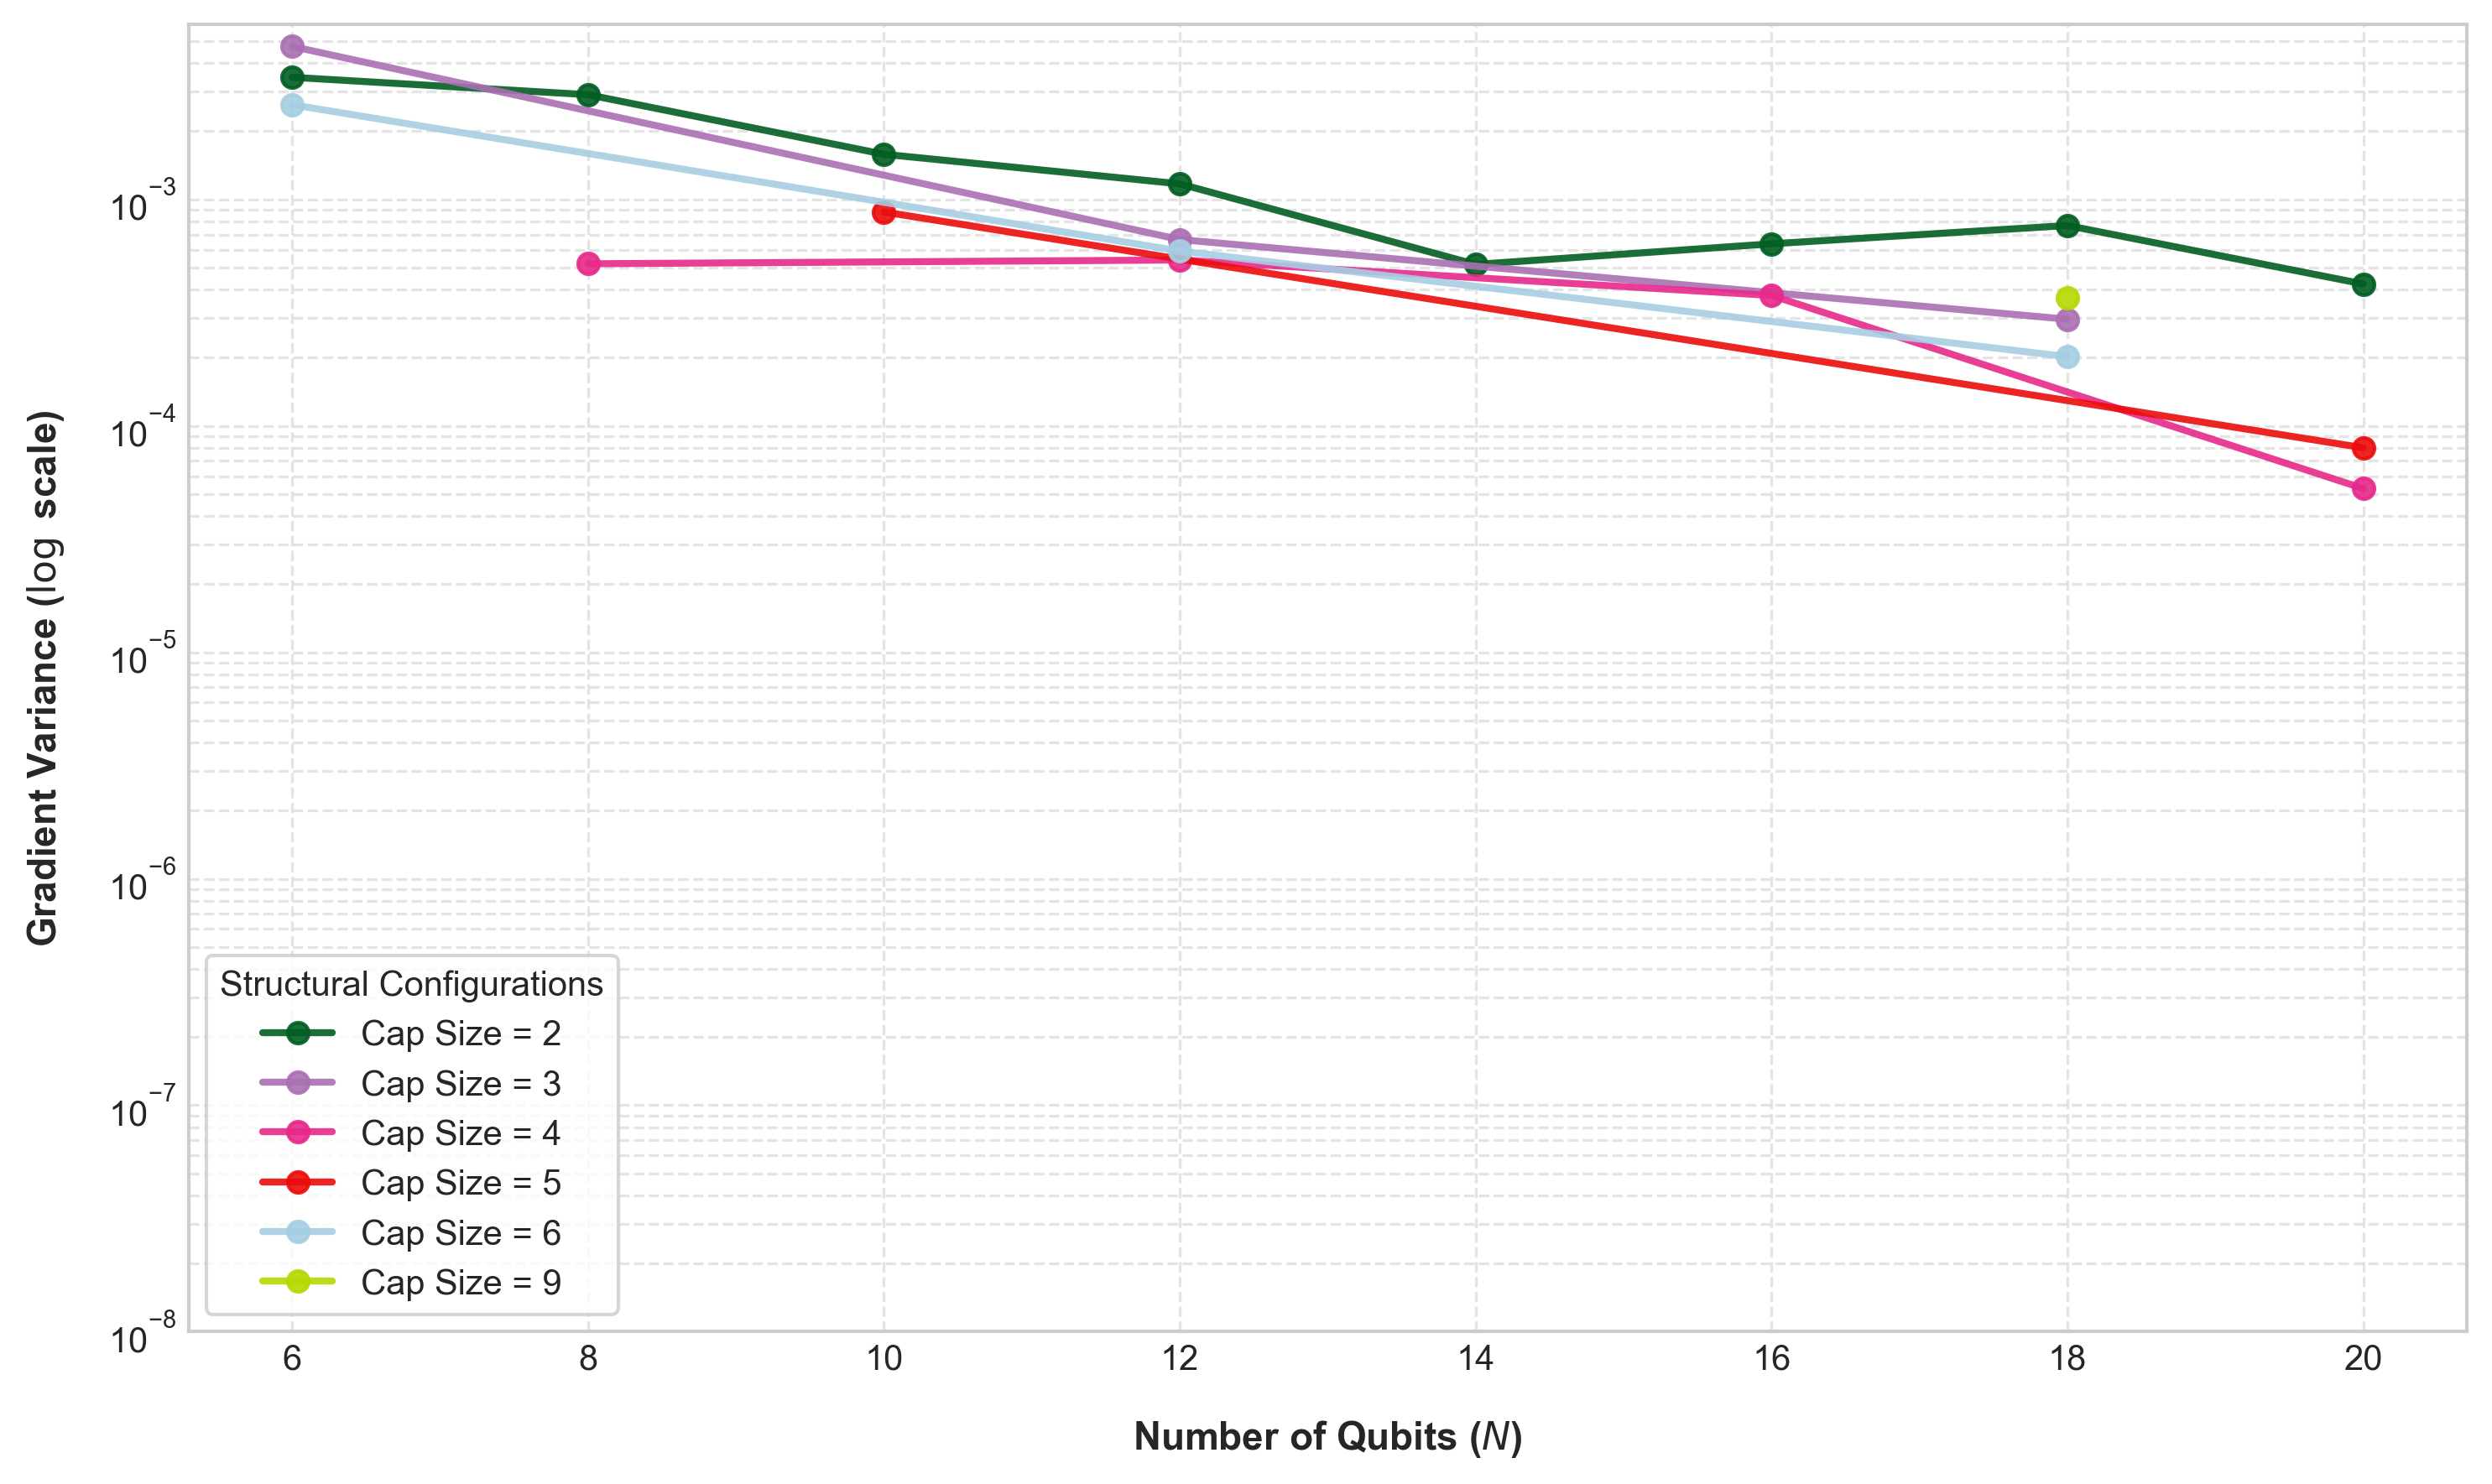

✓ Graph successfully generated and saved to: C:\Users\User\Downloads\Barren-Pleatau-Model\exp8_cap_ablation_plot.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Setup professional style
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Load data
csv_path = r"C:\Users\User\Downloads\Barren-Pleatau-Model\exp8_cap_ablation.csv"

if not os.path.exists(csv_path):
    print(f"Error: Specified path does not exist: {csv_path}")
else:
    df = pd.read_csv(csv_path)
    
    # Get unique cap sizes present in the dataset
    unique_caps = sorted(df['cap_size'].unique())
    
    # Distinct scientific hex colors matching previous theme profile
    colors = ["#025e22", "#aa70b3", '#e7298a', "#eb0c0c", '#a6cee3', "#b5d902"]

    # Loop through each cap size group to plot a line
    for idx, cap in enumerate(unique_caps):
        sub_df = df[df['cap_size'] == cap].sort_values(by='n_qubits')
        
        color = colors[idx % len(colors)]
        
        # Plot mean gradient variance line with uniform 'o' marker
        ax.plot(sub_df['n_qubits'], sub_df['grad_var_mean'], 
                label=f'Cap Size = {cap}', color=color, marker='o', 
                linewidth=2, markersize=6, alpha=0.9)
        
        # Add Standard Deviation bounds shadow area (shaded error bands)
        under_band = sub_df['grad_var_mean'] - sub_df['grad_var_std']
        # Lower bound boundary matrix check to avoid illegal log scale values (< 0)
        under_band = under_band.clip(lower=1e-10) 
        upper_band = sub_df['grad_var_mean'] + sub_df['grad_var_std']
        
      
    # Scale and Labels config
    ax.set_yscale('log')
    ax.set_ylim(bottom=1e-8) 
    ax.set_xlabel('Number of Qubits ($N$)', fontweight='bold', labelpad=12, fontsize=11)
    ax.set_ylabel('Gradient Variance ($\log$ scale)', fontweight='bold', labelpad=12, fontsize=11)
    
    # Precise tick configuration dynamically from values range
    all_qubits = sorted(df['n_qubits'].unique())
    ax.set_xticks(all_qubits)
    
   

    # Legend panel alignment
    ax.legend(title='Structural Configurations', title_fontsize=10, loc='lower left', 
              frameon=True, facecolor='white', edgecolor='0.8')
    
    # Grid configuration matrix
    ax.grid(True, which="both", ls="--", color='0.85', alpha=0.7)

    plt.tight_layout()
    
    # Save isolated ablation snapshot image to directory path
    output_img = os.path.join(os.path.dirname(csv_path), 'exp8_cap_ablation_plot.png')
    plt.savefig(output_img, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"✓ Graph successfully generated and saved to: {output_img}")

In [ ]:
"""
Adaptive Quantum Capsule Network (QCN) — sklearn Digits Binary Classification
==============================================================================
TRUE ADAPTIVE DEPTH:
  Primary   → Gradient Variance based  (Barren Plateau detect)
  Secondary → Performance based        (accuracy plateau detect)

Depth বাড়ার condition:
  1. grad_variance[c] < GRAD_VAR_THRESHOLD  (primary)
     OR
  2. accuracy improvement < ACC_IMPROVE_THRESHOLD  (secondary)
  +  minimum DEPTH_ADAPT_COOLDOWN epochs gap between adaptations
  +  maximum MAX_DEPTH cap

Outputs:
  training_log.csv
  grad_variance_log.csv
  depth_adaptation_log.csv   ← NEW: কোন epoch এ কোন capsule এর depth বদলাল
  effective_dimension.csv
  efficiency_analysis.csv
  capsule_correlation.csv
"""

import os
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# ═══════════════════════════════════════════════════════════════
# 0.  ALL HYPERPARAMETERS
# ═══════════════════════════════════════════════════════════════

DIGIT_A     = 0
DIGIT_B     = 1

N_CAPS      = 4
CAP_SIZE    = 4
DEPTHS      = [2, 2, 2, 2]   # starting depth (low — adaptive বাড়াবে)
MAX_DEPTH   = 6               # কোনো capsule এর depth এর উপরে সীমা

N_EPOCHS    = 30
BATCH_SIZE  = 8
LR          = 0.05

QUICK_EP    = 5
TEST_SIZE   = 0.25
RANDOM_SEED = 42

OUTPUT_DIR  = "C:\\Users\\User\\Downloads\\Barren-Pleatau-Model\\"

# ── Adaptive Depth Hyperparameters ──────────────────────────────
GRAD_VAR_THRESHOLD   = 1e-4   # এর নিচে গেলে → depth বাড়াও (primary)
ACC_IMPROVE_THRESHOLD = 0.005 # এর কম improve হলে → depth বাড়াও (secondary)
DEPTH_ADAPT_COOLDOWN  = 3     # কতো epoch পর পর adapt করা যাবে
ADAPT_CHECK_START     = 5     # কতো epoch পর থেকে adaptation শুরু হবে

# ── Derived constants ────────────────────────────────────────────
N_QUBITS     = N_CAPS * CAP_SIZE
IMG_SIDE     = int(np.sqrt(N_QUBITS))
N_SAMPLES_ED = [100, 500, 1000, 5000, 10000]

assert len(DEPTHS) == N_CAPS,     "len(DEPTHS) must equal N_CAPS"
assert IMG_SIDE ** 2 == N_QUBITS, "N_QUBITS must be a perfect square"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 60)
print(f"  TRUE ADAPTIVE QCN Config")
print(f"  Digits         : {DIGIT_A} vs {DIGIT_B}")
print(f"  Capsules       : {N_CAPS}  x  {CAP_SIZE} qubits  =  {N_QUBITS} total")
print(f"  Start Depths   : {DEPTHS}  (max={MAX_DEPTH})")
print(f"  Grad Threshold : {GRAD_VAR_THRESHOLD}")
print(f"  Acc Threshold  : {ACC_IMPROVE_THRESHOLD}")
print(f"  Cooldown       : {DEPTH_ADAPT_COOLDOWN} epochs")
print(f"  Epochs         : {N_EPOCHS}   Batch: {BATCH_SIZE}   LR: {LR}")
print("=" * 60)

# ═══════════════════════════════════════════════════════════════
# 1.  DATASET  +  PCA PREPROCESSING
# ═══════════════════════════════════════════════════════════════
print(f"\n[Data] Loading sklearn digits ({DIGIT_A} vs {DIGIT_B}) ...")

digits = load_digits()
mask   = (digits.target == DIGIT_A) | (digits.target == DIGIT_B)
X_raw  = digits.data[mask]
y_raw  = digits.target[mask]

y = np.where(y_raw == DIGIT_A, -1.0, 1.0)

pca      = PCA(n_components=N_QUBITS, random_state=RANDOM_SEED)
X_pca    = pca.fit_transform(X_raw)

scaler   = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X_pca)

X_images = X_scaled.reshape(-1, IMG_SIDE, IMG_SIDE)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"  PCA variance explained : {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  Train : {len(X_train)}   Test : {len(X_test)}")

# ═══════════════════════════════════════════════════════════════
# 2.  QUANTUM DEVICE
# ═══════════════════════════════════════════════════════════════
dev = qml.device("default.qubit", wires=N_QUBITS)

# ═══════════════════════════════════════════════════════════════
# 3.  CIRCUIT BUILDER
# ═══════════════════════════════════════════════════════════════
def build_circuit(n_qubits, n_caps, cap_size, depths, device):
    offsets = [0]
    for c in range(n_caps):
        offsets.append(offsets[-1] + depths[c] * cap_size * 4)
    total_params = offsets[-1]
    max_d        = max(depths)

    @qml.qnode(device, diff_method="best")
    def circuit(params, x):
        for i in range(n_qubits):
            qml.Hadamard(wires=i)

        for layer in range(max_d):
            for c in range(n_caps):
                if layer >= depths[c]:
                    continue

                w  = list(range(c * cap_size, (c + 1) * cap_size))
                cp = params[offsets[c]: offsets[c + 1]].reshape(
                         depths[c], cap_size, 4)

                xc = [float(x[c * cap_size + j]) for j in range(cap_size)]

                for j, wire in enumerate(w):
                    qml.RY(xc[j] * cp[layer, j, 3], wires=wire)

                for j, wire in enumerate(w):
                    qml.Rot(cp[layer, j, 0],
                            cp[layer, j, 1],
                            cp[layer, j, 2], wires=wire)

                if layer % 2 == 0:
                    for j in range(len(w) - 1):
                        qml.CNOT(wires=[w[j], w[j + 1]])
                    if len(w) > 2:
                        qml.CNOT(wires=[w[-1], w[0]])

            if layer % 2 == 0:
                ic_offset = (layer // 2) % 2
                for c in range(ic_offset, n_caps - 1, 2):
                    if layer < depths[c] and layer < depths[c + 1]:
                        boundary_a = (c + 1) * cap_size - 1
                        boundary_b = (c + 1) * cap_size
                        qml.CNOT(wires=[boundary_a, boundary_b])

        return qml.math.stack([
            qml.expval(qml.PauliZ(c * cap_size)) for c in range(n_caps)
        ])

    return circuit, total_params, offsets


# ═══════════════════════════════════════════════════════════════
# 4.  LOSS + PREDICTION HELPERS
# ═══════════════════════════════════════════════════════════════
def make_helpers(circuit_fn):
    def predict_one(params, x):
        return qml.math.mean(circuit_fn(params, x))

    def mse_loss(params, X_batch, y_batch):
        preds = qml.math.stack([predict_one(params, x) for x in X_batch])
        return qml.math.mean((preds - y_batch) ** 2)

    def accuracy(params, X, y):
        signs = np.array([float(np.sign(predict_one(params, x))) for x in X])
        signs = np.where(signs == 0, 1.0, signs)
        return float(np.mean(signs == y))

    return predict_one, mse_loss, accuracy


# ═══════════════════════════════════════════════════════════════
# 5.  ADAPTIVE DEPTH ENGINE
# ═══════════════════════════════════════════════════════════════
def check_and_adapt_depths(
    depths, params, offsets,
    cap_grad_vars,          # per-capsule gradient variance list
    prev_acc, curr_acc,
    last_adapt_epoch, epoch,
    cap_size
):
    """
    Returns: (new_depths, new_params, new_offsets, adapted_capsules)
    Priority: Gradient Variance (primary) > Accuracy Plateau (secondary)
    """
    if epoch < ADAPT_CHECK_START:
        return depths, params, offsets, []

    if (epoch - last_adapt_epoch) < DEPTH_ADAPT_COOLDOWN:
        return depths, params, offsets, []

    adapted = []
    new_depths = list(depths)

    for c in range(N_CAPS):
        if new_depths[c] >= MAX_DEPTH:
            continue

        grad_trigger = cap_grad_vars[c] < GRAD_VAR_THRESHOLD
        acc_trigger  = (curr_acc - prev_acc) < ACC_IMPROVE_THRESHOLD

        # Primary: gradient → adapt
        # Secondary: accuracy plateau → adapt (only if grad is also low-ish)
        if grad_trigger or (acc_trigger and cap_grad_vars[c] < GRAD_VAR_THRESHOLD * 10):
            reason = "grad_var" if grad_trigger else "acc_plateau"
            new_depths[c] += 1
            adapted.append((c, depths[c], new_depths[c], reason,
                             cap_grad_vars[c]))

    if not adapted:
        return depths, params, offsets, []

    # Rebuild circuit + expand params (new params init near 0)
    new_offsets = [0]
    for c in range(N_CAPS):
        new_offsets.append(new_offsets[-1] + new_depths[c] * cap_size * 4)
    new_total = new_offsets[-1]

    new_params = np.zeros(new_total, requires_grad=True)
    for c in range(N_CAPS):
        old_size = offsets[c + 1] - offsets[c]
        new_params[new_offsets[c]: new_offsets[c] + old_size] = \
            params[offsets[c]: offsets[c + 1]]
        # extra new params → small random init
        extra_start = new_offsets[c] + old_size
        extra_end   = new_offsets[c + 1]
        if extra_end > extra_start:
            new_params[extra_start:extra_end] = \
                np.random.uniform(0, 0.1, extra_end - extra_start)

    return new_depths, new_params, new_offsets, adapted


# ═══════════════════════════════════════════════════════════════
# 6.  INITIAL BUILD
# ═══════════════════════════════════════════════════════════════
current_depths = list(DEPTHS)
circuit, total_params, offsets = build_circuit(
    N_QUBITS, N_CAPS, CAP_SIZE, current_depths, dev
)
predict_one, mse_loss, accuracy = make_helpers(circuit)
print(f"\nCircuit ready  |  total_params = {total_params}  |  depths = {current_depths}")

# ═══════════════════════════════════════════════════════════════
# 7.  TRAINING LOOP  +  ADAPTIVE DEPTH
# ═══════════════════════════════════════════════════════════════
print(f"\n[Train] Starting Adaptive Training ({N_EPOCHS} epochs) ...")

np.random.seed(RANDOM_SEED)
params    = np.random.uniform(0, np.pi, total_params, requires_grad=True)
optimizer = qml.AdamOptimizer(stepsize=LR)

training_log      = []
grad_var_log      = []
depth_adapt_log   = []

prev_test_acc     = 0.0
last_adapt_epoch  = 0

for epoch in range(1, N_EPOCHS + 1):

    grad_fn = qml.grad(mse_loss)

    perm   = np.random.permutation(len(X_train))
    X_shuf = X_train[perm]
    y_shuf = y_train[perm]

    epoch_loss, n_batches = 0.0, 0

    for start in range(0, len(X_train), BATCH_SIZE):
        Xb = X_shuf[start: start + BATCH_SIZE]
        yb = y_shuf[start: start + BATCH_SIZE]
        params, loss_val = optimizer.step_and_cost(
            lambda p: mse_loss(p, Xb, yb), params
        )
        epoch_loss += float(loss_val)
        n_batches  += 1

    avg_loss  = epoch_loss / n_batches
    train_acc = accuracy(params, X_train, y_train)
    test_acc  = accuracy(params, X_test,  y_test)

    # ── Per-capsule gradient variance ────────────────────────────
    grad_samples = []
    eval_indices = perm[:min(16, len(X_train))]

    for idx in eval_indices:
        g = grad_fn(params,
                    X_train[idx: idx + 1],
                    y_train[idx: idx + 1])
        grad_samples.append(np.array(g[0]).flatten())

    grad_samples    = np.array(grad_samples)           # (16, total_params)
    param_variances = np.var(grad_samples, axis=0)     # (total_params,)

    # per-capsule variance (mean of that capsule's param variances)
    cap_grad_vars = []
    for c in range(N_CAPS):
        start_idx = offsets[c]
        end_idx   = offsets[c + 1]
        cap_grad_vars.append(float(np.mean(param_variances[start_idx:end_idx])))

    epoch_grad_var_mean = float(np.mean(param_variances))
    epoch_grad_var_std  = float(np.std(param_variances))

    # ── Adaptive Depth Check ──────────────────────────────────────
    current_depths, params, offsets, adapted = check_and_adapt_depths(
        current_depths, params, offsets,
        cap_grad_vars,
        prev_test_acc, test_acc,
        last_adapt_epoch, epoch,
        CAP_SIZE
    )

    if adapted:
        # Rebuild circuit + helpers with new depths
        circuit, total_params, offsets = build_circuit(
            N_QUBITS, N_CAPS, CAP_SIZE, current_depths, dev
        )
        predict_one, mse_loss, accuracy = make_helpers(circuit)
        optimizer = qml.AdamOptimizer(stepsize=LR)  # reset optimizer state
        last_adapt_epoch = epoch

        for (c, old_d, new_d, reason, gv) in adapted:
            print(f"  *** ADAPT Epoch {epoch}: Capsule {c}  "
                  f"depth {old_d}→{new_d}  reason={reason}  "
                  f"grad_var={gv:.3e} ***")
            depth_adapt_log.append({
                "Epoch":       epoch,
                "Capsule":     c,
                "Old_Depth":   old_d,
                "New_Depth":   new_d,
                "Reason":      reason,
                "Grad_Var":    f"{gv:.4e}",
                "Test_Acc":    round(test_acc, 4),
            })

    training_log.append({
        "Epoch":         epoch,
        "Loss":          round(avg_loss,  6),
        "Train_Acc":     round(train_acc, 4),
        "Test_Acc":      round(test_acc,  4),
        "Depths":        str(current_depths),
        "Grad_Var_Mean": f"{epoch_grad_var_mean:.4e}",
        "Grad_Var_Std":  f"{epoch_grad_var_std:.4e}",
        "Cap_Grad_Vars": str([f"{v:.3e}" for v in cap_grad_vars]),
    })

    grad_var_log.append({
        "Epoch":         epoch,
        "Grad_Var_Mean": epoch_grad_var_mean,
        "Grad_Var_Std":  epoch_grad_var_std,
    })

    prev_test_acc = test_acc

    print(f"  Epoch {epoch:>3}/{N_EPOCHS}  |  "
          f"loss={avg_loss:.4f}  "
          f"train={train_acc:.3f}  "
          f"test={test_acc:.3f}  "
          f"depths={current_depths}  "
          f"grad_var={epoch_grad_var_mean:.3e}")

# ── Save CSVs ────────────────────────────────────────────────────
pd.DataFrame(training_log).to_csv(
    f"{OUTPUT_DIR}training_log.csv", index=False)
print(f"\n  Saved -> training_log.csv")

pd.DataFrame(grad_var_log).to_csv(
    f"{OUTPUT_DIR}grad_variance_log.csv", index=False)
print(f"  Saved -> grad_variance_log.csv")

pd.DataFrame(depth_adapt_log).to_csv(
    f"{OUTPUT_DIR}depth_adaptation_log.csv", index=False)
print(f"  Saved -> depth_adaptation_log.csv")

current_acc = accuracy(params, X_test, y_test)
print(f"\n  Final Test Accuracy : {current_acc*100:.2f}%")
print(f"  Final Depths        : {current_depths}")

# ═══════════════════════════════════════════════════════════════
# 8.  HELPER: GATE COUNT
# ═══════════════════════════════════════════════════════════════
def get_gate_counts(depths, n_caps, cap_size):
    total_ry   = sum(depths) * cap_size
    total_rot  = sum(depths) * cap_size
    total_cnot = sum(
        (cap_size if cap_size > 2 else cap_size - 1) * (d // 2 + 1)
        for d in depths
    )
    total_cnot += (n_caps - 1) * (max(depths) // 2)
    return total_ry + total_rot + total_cnot

# ═══════════════════════════════════════════════════════════════
# 9.  EXPERIMENT 1 — EFFECTIVE DIMENSION
# ═══════════════════════════════════════════════════════════════
print("\n[Exp 1] Computing Effective Dimension ...")

F       = qml.gradients.quantum_fisher(circuit)(params, X_test[0])
trace_F = float(np.trace(F))
F_hat   = (total_params * F) / trace_F if trace_F > 0 else F

ed_results = []
for n in N_SAMPLES_ED:
    scale    = n / (2 * np.pi * np.log(n))
    mat      = np.eye(total_params) + scale * F_hat
    sign, ld = np.linalg.slogdet(mat)
    eff_dim  = float((2 * ld) / np.log(scale)) if sign > 0 else float("nan")
    ed_results.append({"Sample_Size": n, "Effective_Dimension": eff_dim})
    print(f"  n={n:>6}  eff_dim={eff_dim:.4f}")

pd.DataFrame(ed_results).to_csv(
    f"{OUTPUT_DIR}effective_dimension.csv", index=False)
print(f"  Saved -> effective_dimension.csv")

# ═══════════════════════════════════════════════════════════════
# 10. EXPERIMENT 2 — EFFICIENCY ANALYSIS
# ═══════════════════════════════════════════════════════════════
print("\n[Exp 2] Efficiency Analysis ...")

def train_quick(depths_cfg, n_ep=QUICK_EP):
    circ_tmp, tp, _ = build_circuit(N_QUBITS, N_CAPS, CAP_SIZE, depths_cfg, dev)
    _, mse_loss_tmp, accuracy_tmp = make_helpers(circ_tmp)

    np.random.seed(RANDOM_SEED)
    p   = np.random.uniform(0, np.pi, tp, requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=LR)

    for _ in range(n_ep):
        perm = np.random.permutation(len(X_train))
        for s in range(0, len(X_train), BATCH_SIZE):
            Xb = X_train[perm[s: s + BATCH_SIZE]]
            yb = y_train[perm[s: s + BATCH_SIZE]]
            p, _ = opt.step_and_cost(
                lambda pp, _Xb=Xb, _yb=yb: mse_loss_tmp(pp, _Xb, _yb), p
            )

    return accuracy_tmp(p, X_test, y_test)

depths_d2 = [2] * N_CAPS
depths_d4 = [4] * N_CAPS

print(f"  Training Fixed_D2 {depths_d2} ({QUICK_EP} epochs) ...")
acc_d2 = train_quick(depths_d2)
print(f"  Fixed_D2  test_acc={acc_d2:.3f}")

print(f"  Training Fixed_D4 {depths_d4} ({QUICK_EP} epochs) ...")
acc_d4 = train_quick(depths_d4)
print(f"  Fixed_D4  test_acc={acc_d4:.3f}")

efficiency_data = [
    {
        "Model":      f"Adaptive_QCapsule {current_depths}",
        "Gate_Count": get_gate_counts(current_depths, N_CAPS, CAP_SIZE),
        "Accuracy":   round(current_acc, 4),
    },
    {
        "Model":      f"Fixed_QCapsule_D2 {depths_d2}",
        "Gate_Count": get_gate_counts(depths_d2,      N_CAPS, CAP_SIZE),
        "Accuracy":   round(acc_d2, 4),
    },
    {
        "Model":      f"Fixed_QCapsule_D4 {depths_d4}",
        "Gate_Count": get_gate_counts(depths_d4,      N_CAPS, CAP_SIZE),
        "Accuracy":   round(acc_d4, 4),
    },
]

pd.DataFrame(efficiency_data).to_csv(
    f"{OUTPUT_DIR}efficiency_analysis.csv", index=False)
print(f"  Saved -> efficiency_analysis.csv")

# ═══════════════════════════════════════════════════════════════
# 11. EXPERIMENT 3 — CAPSULE CORRELATION MATRIX
# ═══════════════════════════════════════════════════════════════
print("\n[Exp 3] Capsule Correlation Matrix ...")

n_corr_samples  = min(50, len(X_test))
capsule_outputs = []
for x in X_test[:n_corr_samples]:
    out = circuit(params, x)
    capsule_outputs.append(np.array(out))

df_caps = pd.DataFrame(
    np.array(capsule_outputs),
    columns=[f"Capsule_{i}" for i in range(N_CAPS)]
)
corr_matrix = df_caps.corr()
corr_matrix.to_csv(f"{OUTPUT_DIR}capsule_correlation.csv")
print(f"  Saved -> capsule_correlation.csv")

# ═══════════════════════════════════════════════════════════════
# 12. DONE
# ═══════════════════════════════════════════════════════════════
print(f"""
All experiments complete.
  Digit pair        : {DIGIT_A} vs {DIGIT_B}
  Initial Depths    : {DEPTHS}
  Final Depths      : {current_depths}
  Final Test Acc    : {current_acc*100:.2f}%
  Files saved in    : {OUTPUT_DIR}
    training_log.csv           (Loss + Acc + Depths + Grad Variance)
    grad_variance_log.csv      (Epoch vs Gradient Variance)
    depth_adaptation_log.csv   (কোন epoch এ কোন capsule adapt হলো)
    effective_dimension.csv
    efficiency_analysis.csv
    capsule_correlation.csv
""")

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

file_path = r"C:\Users\User\Downloads\Barren-Pleatau-Model\capsule_correlation.csv"
df = pd.read_csv(file_path, index_col=0)

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

# Custom annotation array — diagonal-এ "1.00", বাকিতে ".3f"
annot_array = np.empty_like(df.values, dtype=object)
for i in range(df.shape[0]):
    for j in range(df.shape[1]):
        if i == j:
            annot_array[i, j] = "1.00"
        else:
            annot_array[i, j] = f"{df.values[i, j]:.3f}"

sns.heatmap(
    df,
    ax=ax,
    annot=annot_array,
    fmt="",              # ← খালি রাখতে হবে, না হলে error
    cmap=plt.cm.RdBu_r,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor="#e0e0e0",
    square=True,
    annot_kws={"size": 10, "weight": "bold"},
    cbar_kws={"shrink": 0.82, "label": "Pearson Correlation"},
)

# Diagonal cell-এর text color সাদা করা
for i in range(len(df)):
    ax.texts[i * len(df) + i].set_color("white")

# Colorbar label style
ax.figure.axes[-1].yaxis.label.set(fontsize=10, fontweight="bold")


ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.tick_params(length=0)

plt.tight_layout()

output_path = os.path.join(os.path.dirname(file_path), "capsule_correlation_heatmap.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.close()
print(f"✓ Saved: {output_path}")

✓ Saved: C:\Users\User\Downloads\Barren-Pleatau-Model\capsule_correlation_heatmap.png


In [25]:
import os
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ─── ডাটা লোড ও প্রিপারেশন ───
file_path = r"C:\Users\User\Downloads\Barren-Pleatau-Model\efficiency_analysis.csv"
df = pd.read_csv(file_path)

# এক্স-অ্যাক্সিসের জন্য ২-লাইনের প্রফেশনাল লেবেল (মডেল এবং লেয়ার আলাদা করে)
# এখানে \n (New line) ব্যবহার করে লেয়ার/ডেপথের তথ্য নিচে নামিয়ে দেওয়া হয়েছে
df["Short"] = [
    "Adaptive\nQCapsule\n[4, 3, 3, 4]",
    "Fixed\nQCapsule\n[2, 2, 2, 2]",
    "Fixed\nQCapsule\n[4, 4, 4, 4]",
]

# ─── প্লট কনফিগারেশন (Academic Style) ───
plt.rcParams["font.family"] = "serif"  # জার্নাল পেপারের উপযোগী Serif ফন্ট
fig, ax1 = plt.subplots(figsize=(8.5, 5), dpi=300)  # সামান্য হাইট বাড়ানো হলো লেবেলের জন্য

x = np.arange(len(df))
width = 0.28  # বারের উইডথ কিছুটা কমানো হলো যেন দেখতে আরও স্লিম ও ক্লিন লাগে

# ডাবল ওয়াই-অ্যাক্সিসের জন্য ২টি আলাদা এবং ক্লাসি কালার
color_gate = "#1f77b4"  # স্টিল ব্লু (Gate Count)
color_acc = "#e377c2"  # রোজ/ম্যাজেন্টা (Accuracy)

# ─── বাম Y-axis: Gate Count (Bars) ───
bars1 = ax1.bar(
    x - width / 2,
    df["Gate_Count"],
    width=width,
    color=color_gate,
    alpha=0.85,
    edgecolor="#222222",
    linewidth=0.8,
    zorder=3,
)

ax1.set_ylabel("Gate Count", fontsize=11, fontweight="bold", color="#111111")
ax1.set_ylim(0, max(df["Gate_Count"]) * 1.15)
ax1.tick_params(axis="y", labelsize=10)

# এক্স-অ্যাক্সিস সেটআপ (এখানেই লেয়ারের টেক্সটগুলো বসবে)
ax1.set_xticks(x)
ax1.set_xticklabels(
    df["Short"], fontsize=9.5, fontweight="normal"
)  # লেবেলগুলো স্পষ্ট দেখাবে

# Gate Count-এর ডাটা লেবেল (বারের ওপরে)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (max(df["Gate_Count"]) * 0.015),
        f"{int(yval)}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#222222",
    )

# ─── ডান Y-axis: Accuracy (Bars) ───
ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + width / 2,
    df["Accuracy"],
    width=width,
    color=color_acc,
    alpha=0.85,
    edgecolor="#222222",
    linewidth=0.8,
    zorder=3,
)

ax2.set_ylabel(
    "Accuracy (Classification)", fontsize=11, fontweight="bold", color="#111111"
)
ax2.set_ylim(0.0, 1.15)
ax2.tick_params(axis="y", labelsize=10)

# Accuracy-এর ডাটা লেবেল (বারের ওপরে ৪ দশমিক ঘর পর্যন্ত)
for bar in bars2:
    yval = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.01,
        f"{yval:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#222222",
    )

# ─── গ্রিড এবং আউটলাইন ক্লিনিং ───
ax1.grid(True, axis="y", linestyle=":", alpha=0.5, zorder=0)

# ওপরের বর্ডার (Top Spine) হাইড করা (Modern IEEE/Nature Style)
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

# ─── লিজেন্ড (Legend) ───
legend_handles = [
    mpatches.Patch(
        facecolor=color_gate, edgecolor="#222222", label="Total Gate Count"
    ),
    mpatches.Patch(facecolor=color_acc, edgecolor="#222222", label="Accuracy"),
]
ax1.legend(
    handles=legend_handles,
    loc="upper left",
    fontsize=9.5,
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
)



plt.tight_layout()

output_path = os.path.join(
    os.path.dirname(file_path), "academic_efficiency_layers_plot.png"
)
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"✓ Layer-based Research Plot Saved: {output_path}")

✓ Layer-based Research Plot Saved: C:\Users\User\Downloads\Barren-Pleatau-Model\academic_efficiency_layers_plot.png


In [33]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ─── ১. ডাটা লোড ও প্রিপারেশন ───
file_path = (
    r"C:\Users\User\Downloads\Barren-Pleatau-Model\effective_dimension.csv"
)
df = pd.read_csv(file_path)

# ─── ২. প্লট কনফিগারেশন (Academic Style) ───
plt.rcParams["font.family"] = "serif"  # LaTeX/IEEE পেপারের জন্য Serif ফন্ট উত্তম
fig, ax = plt.subplots(
    figsize=(7.5, 4.8), dpi=300
)  # স্ট্যান্ডার্ড জার্নাল সাইজ ও হাই-রেজোলিউশন

# প্রফেশনাল ডিপ ব্লু কালার ও মার্কার সেটআপ
color_line = "#1a5276"  # ক্লাসিক একাডেমিক ব্লু

# লাইন প্লট তৈরি
ax.plot(
    df["Sample_Size"],
    df["Effective_Dimension"],
    marker="o",  # বৃত্তাকার মার্কার
    markersize=7,
    linestyle="-",
    linewidth=2,
    color=color_line,
    label="Effective Dimension",
    zorder=3,
)

# ─── ৩. এক্স ও ওয়াই অ্যাক্সিস কনফিগারেশন ───
# এক্স-অ্যাক্সিসকে লগ স্কেলে রূপান্তর (যেহেতু ডাটা ১০০ থেকে ১০,০০০ পর্যন্ত বিস্তৃত)
ax.set_xscale("log")

# এক্স-অ্যাক্সিসের লেবেলগুলো সুনির্দিষ্ট করা
ax.set_xticks(df["Sample_Size"])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

# লেবেল এবং টাইটেল সেটআপ
ax.set_xlabel(
    "Sample Size ($N$)", fontsize=11, fontweight="bold", labelpad=10
)
ax.set_ylabel("Effective Dimension", fontsize=11, fontweight="bold", labelpad=10)


# ─── ৪. ডাটা লেবেল ও নিখুঁত ফরম্যাটিং ───
# প্রতিটি পয়েন্টের ওপরে তার সুনির্দিষ্ট মান (২ দশমিক স্থান পর্যন্ত) বসানো
for x, y in zip(df["Sample_Size"], df["Effective_Dimension"]):
    ax.annotate(
        f"{y:.2f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),  # পয়েন্ট থেকে সামান্য ওপরে লেবেল
        ha="center",
        fontsize=9,
        fontweight="bold",
        color="#222222",
    )

# ওয়াই-অ্যাক্সিসের রেঞ্জ কিছুটা বাড়িয়ে দেওয়া যেন লেবেলগুলো কেটে না যায়
ax.set_ylim(min(df["Effective_Dimension"]) * 0.92, max(df["Effective_Dimension"]) * 1.08)

# ─── ৫. গ্রিড এবং স্পাইনস (Spines) ক্লিনিং ───
ax.grid(
    True, which="both", linestyle=":", alpha=0.5, zorder=0
)  # হালকা ডটেড গ্রিডলাইন
ax.spines["top"].set_visible(False)  # ওপরের বর্ডার রিমুভ
ax.spines["right"].set_visible(False)  # ডানদিকের বর্ডার রিমুভ
ax.tick_params(axis="both", which="major", labelsize=9.5)

# ─── ৬. প্লট সংরক্ষণ ───
plt.tight_layout()

output_path = os.path.join(
    os.path.dirname(file_path), "effective_dimension_research_plot.png"
)
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"✓ Research-grade Plot Saved Successfully: {output_path}")

✓ Research-grade Plot Saved Successfully: C:\Users\User\Downloads\Barren-Pleatau-Model\effective_dimension_research_plot.png


In [32]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ─── ১. ডাটা পাথ এবং লোড ───
dir_path = r"C:\Users\User\Downloads\Barren-Pleatau-Model"
grad_file = os.path.join(dir_path, "grad_variance_log.csv")
train_file = os.path.join(dir_path, "training_log.csv")

df_grad = pd.read_csv(grad_file)
df_train = pd.read_csv(train_file)

# ─── ২. প্লট কনফিগারেশন (Academic Style) ───
plt.rcParams["font.family"] = "serif"  # জার্নাল পেপারের উপযোগী Serif ফন্ট
fig, ax1 = plt.subplots(figsize=(8.5, 5), dpi=300)  # হাই-রেজোলিউশন সিঙ্গেল প্যানেল

# প্রফেশনাল কালার স্কিম
color_train = "#1f77b4"  # নীল (Train Acc)
color_test = "#2ca02c"  # সবুজ (Test Acc)
color_grad = "#7f7f7f"  # মডার্ন গ্রে (Gradient Variance)

# ─── ৩. বাম Y-axis: Accuracy (Train & Test) ───
(line1,) = ax1.plot(
    df_train["Epoch"],
    df_train["Train_Acc"],
    label="Train Accuracy",
    color=color_train,
    linewidth=2,
    marker="o",
    markersize=4.5,
    zorder=4,
)
(line2,) = ax1.plot(
    df_train["Epoch"],
    df_train["Test_Acc"],
    label="Test Accuracy",
    color=color_test,
    linewidth=2,
    marker="o",
    markersize=4.5,
    zorder=4,
)

ax1.set_xlabel("Epoch", fontsize=11, fontweight="bold", labelpad=8)
ax1.set_ylabel("Accuracy", fontsize=11, fontweight="bold", color="#111111")
ax1.set_ylim(0.82, 1.01)  # অ্যাকুরেসির ট্রেন্ড অনুযায়ী অপ্টিমাইজড রেঞ্জ
ax1.tick_params(axis="y", labelsize=10)
ax1.grid(True, linestyle=":", alpha=0.5, zorder=0)

# ─── ৪. ডান Y-axis: Gradient Variance ───
ax2 = ax1.twinx()

(line3,) = ax2.plot(
    df_grad["Epoch"],
    df_grad["Grad_Var_Mean"],
    label="Gradient Variance Mean",
    color=color_grad,
    linewidth=1.8,
    linestyle="--",
    marker="^",
    markersize=4.5,
    zorder=3,
)

ax2.set_ylabel(
    "Gradient Variance", fontsize=11, fontweight="bold", color=color_grad
)
ax2.tick_params(axis="y", labelcolor=color_grad, labelsize=10)

# সায়েন্টিফিক ই-নোটেশন অন করা (যেমন: 1e-3) যেহেতু মানগুলো খুব ছোট
ax2.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

# Shaded region চলে যাওয়ায় সরাসরি Mean-এর সর্বোচ্চ মানের ওপর ভিত্তি করে লিমিট সেট
ax2.set_ylim(0, max(df_grad["Grad_Var_Mean"]) * 1.2)

# ─── ৫. লিজেন্ড কম্বিনেশন ও ক্লিনিং ───
# সবগুলো লাইনকে একটি মাত্র ক্ল্যাসিক লিজেন্ড বক্সে আনা হলো
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(
    lines,
    labels,
    loc="lower right",  # গ্রাফের ডানদিকের নিচের খালি জায়গায় সেট করা হলো
    fontsize=9.5,
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
)

# বর্ডার (Top Spines) হাইড করা
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)


# ─── ৬. প্লট সংরক্ষণ ───
plt.tight_layout()
output_path = os.path.join(dir_path, "accuracy_vs_gradient_variance.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"✓ Unified Research Plot (Without Shading) Saved: {output_path}")

✓ Unified Research Plot (Without Shading) Saved: C:\Users\User\Downloads\Barren-Pleatau-Model\accuracy_vs_gradient_variance.png
